<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Requirements:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 
Compatible with data_handling.py and fit_FMR_class.py (currently only Generalizing-complex-fits branch)
<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
V Original
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 

In [4]:
import h5py
import numpy as np 
import sys

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append(r"C:\Users\840 G5\OneDrive - Higher Education Commission\Documents\GitHub\VNA_analysis")
from data_handling import Analysis_FMR, FitStore
import fit_FMR_class as models
import complex_fits as fits
import fitting_functions as funcs
import resonance_functions as res_func

import ipywidgets as widgets
from ipywidgets import interact

from scipy.optimize import curve_fit

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Files Information:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
Fill in the information about the files to be analyzed. Create a class entity for each file with Analysis_PSWS()

In [5]:
#Folders where file are. Keep the r to use raw string in Windows.
address1 = Path(r"E:\FZU_DATA\OneDrive_1_6-8-2026\Pt_side_new_params\FMR_2026-06-05")

In [6]:
file_name_1 = "2026-06-05_FMR_fsw_0Ato19p5Ain81_0p5to28p5GHz_0dBm_17-23.h5_try.ma8"

In [7]:
sample = "YIG_Jone_FMR"

In [8]:
geometry = "inP" #either "inP" or "outP"

In [9]:
vna_ref_subtracted = True #Was a reference already subtracted during measurements?

In [10]:
ansy1 = Analysis_FMR(address1, file_name_1, sample, "FZU_FMR", geometry, vna_ref_subtracted)

In [11]:
store_in_origin = True #True if you wnat to store fit results in orignal file, otherwise another h5f file is created in the same directory

In [12]:
if store_in_origin:
    newFile = ansy1.file
else:
    newfile_name =  s.replace(".h5.ma8", "_LorentzFits.h5")
    newFile = address1/newfile_name

fits_storage = FitStore (newFile, group="Lorentzian fitting")

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Data visualization:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
plot_dL_slider() allows one to preview the data for each field to select the best reference subraction.

In [13]:
ansy1.plot_dij_slider('d_S', n_0=5)

interactive(children=(IntSlider(value=5, description='Field index', max=80, readout_format='.0f'), Output()), …

In [14]:
#Ref. subtraction

In [15]:
ansy1.subtract_ref(single=False, fit=True, nb_g=1, ref_indx= 0) 
############It is saving a fuuuuull matrix of reference, no good

In [16]:
#Recheck data after new ref

In [17]:
ansy1.plot_dij_slider('d_S', n_0=5)

interactive(children=(IntSlider(value=5, description='Field index', max=80, readout_format='.0f'), Output()), …

In [18]:
# Example of a single fit

{'Ar': 5.5060505747306655e-05, 'Ai': 2.4059648459270765e-05, 'fo': 24.9, 'df': 0.01, 're0': 0.0, 'im0': 0.0}
Initial simplex fit


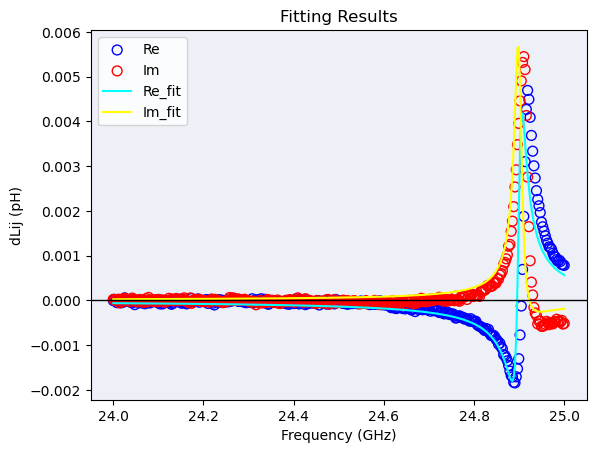

Final fit and results


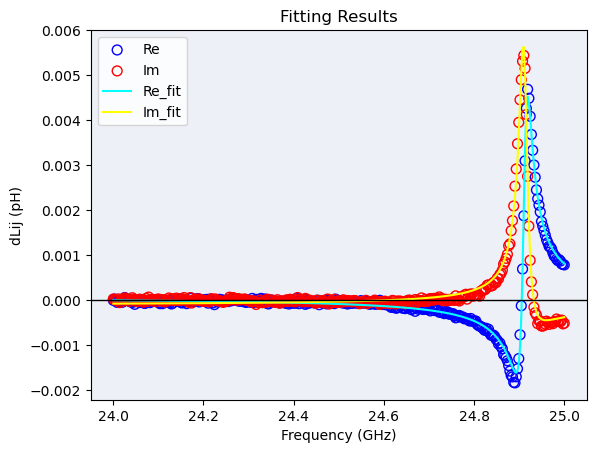


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.293e-05      3.633e-07         U        No
Ai                     3.198e-05      3.633e-07         U        No
fo                       24.9119      7.947e-05       GHz        No
df                        0.0115      7.947e-05       GHz        No
re0                    6.464e-05      4.050e-06         U        No
im0                   -1.141e-04      4.050e-06         U        No
----------------------------------------------------------------------
The phase is: 26.93851515619752


In [19]:
ini_vals = [1, 1, 24.85, 0.028, 0, 0] #A, w, fres, fper, fref, re0, im0
H_index = 13

f_min, f_max = 24, 25 #GHz
f_array = ansy1.freqs
y_array_re, y_array_im = ansy1.d_S("21R")[H_index], ansy1.d_S("21I")[H_index]

model = models.ComplexLorentzian_freq()
fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
    f_array, y_array_re , y_array_im, model)
fitter.fix(fo=24.9, df=0.01, re0=0, im0=0) # Parameters to be fixed, empty otherwise
opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
print(opt_p0)
print("Initial simplex fit")
fitter.plot_fit_simplex_wpm()

new_p0 = np.array(list(opt_p0.values()), dtype=float)
fitter.update_p0(new_p0)

params, cov = fitter.fit(simplex_b=False)
print("Final fit and results")
fitter.plot_fit()
fitter.summary()
print(f"The phase is: {model.phase_deg(**params)}")

In [48]:
#If we are happy with the fit, we can save it.

In [20]:
fit_dict = fitter.export_fit_dict()

fits_storage.save(index=H_index,field=float(ansy1.calc_field("inP")[H_index]),fit_dict=fit_dict)

In [21]:
# Automatic fitting of entire spectra. Enter the estimated parameters for the Kittel model guiding the automatic fitting.

Guide freq.=30.203297337921214
0


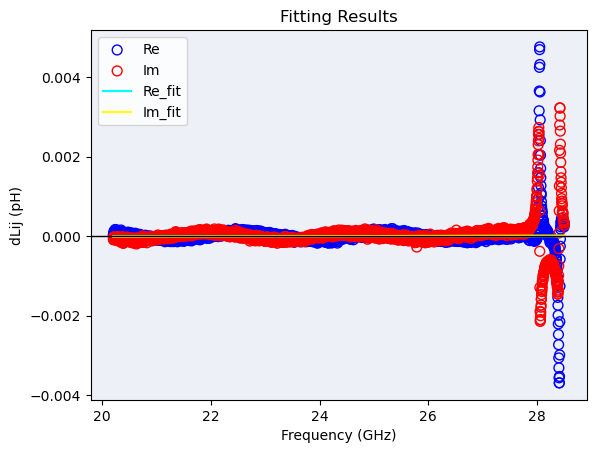


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.0014         0.2187         U        No
Ai                        0.0079         0.2187         U        No
fo                       70.0000       617.5970       GHz        No
df                     1.001e-04       617.5953       GHz        No
re0                    2.655e-05         0.0024         U        No
im0                   -1.760e-04         0.0024         U        No
----------------------------------------------------------------------
Guide freq.=29.93057295606664
1


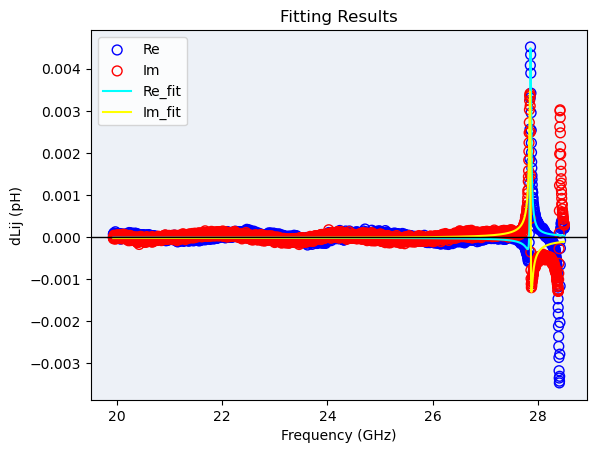


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.801e-05      9.850e-07         U        No
Ai                     5.292e-05      9.850e-07         U        No
fo                       27.8565      2.883e-04       GHz        No
df                        0.0125      2.883e-04       GHz        No
re0                   -1.341e-05      3.750e-06         U        No
im0                   -3.257e-05      3.750e-06         U        No
----------------------------------------------------------------------
Guide freq.=29.63914623448199
2


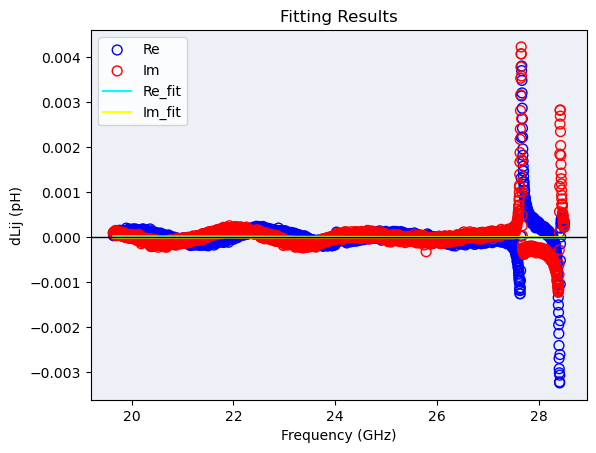


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.0073         0.1766         U        No
Ai                        0.0025         0.1766         U        No
fo                       70.0000       519.9589       GHz        No
df                        2.0000       519.9590       GHz        No
re0                    1.632e-04         0.0019         U        No
im0                   -6.810e-05         0.0019         U        No
----------------------------------------------------------------------
Guide freq.=29.33926841674898
3


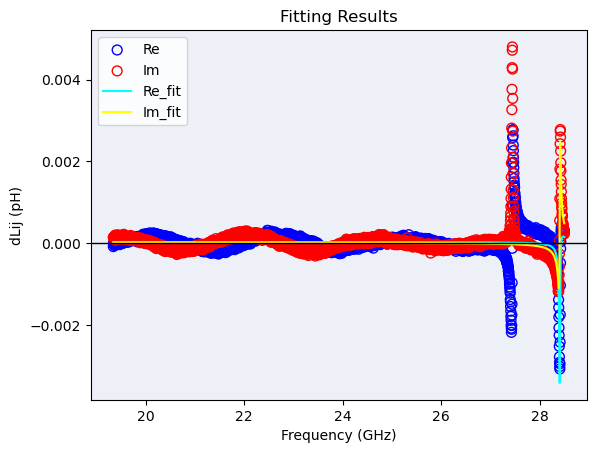


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.664e-05      1.296e-06         U        No
Ai                    -4.090e-05      1.296e-06         U        No
fo                       28.4100      4.969e-04       GHz        No
df                        0.0123      4.969e-04       GHz        No
re0                    3.054e-05      4.621e-06         U        No
im0                    1.584e-05      4.621e-06         U        No
----------------------------------------------------------------------
Guide freq.=29.042485252643374
4


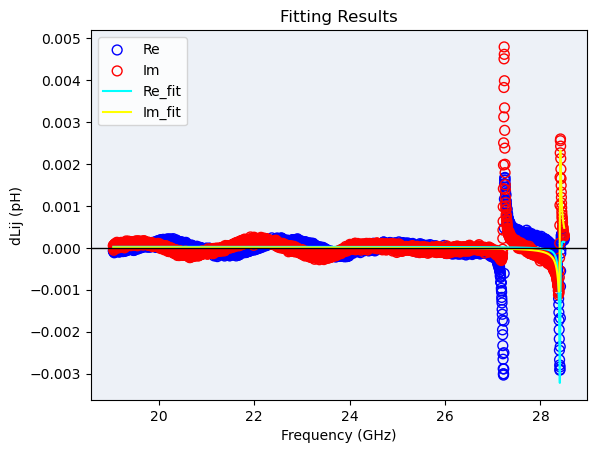


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.609e-05      1.265e-06         U        No
Ai                    -4.027e-05      1.265e-06         U        No
fo                       28.4098      5.153e-04       GHz        No
df                        0.0129      5.153e-04       GHz        No
re0                    2.559e-05      4.336e-06         U        No
im0                    1.283e-05      4.336e-06         U        No
----------------------------------------------------------------------
Guide freq.=28.736080377516444
5


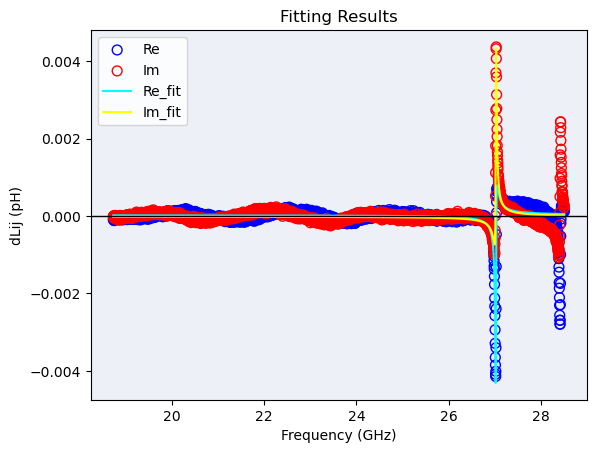


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.441e-05      8.249e-07         U        No
Ai                    -4.334e-05      8.249e-07         U        No
fo                       27.0209      2.277e-04       GHz        No
df                        0.0122      2.277e-04       GHz        No
re0                    2.128e-05      2.991e-06         U        No
im0                   -1.349e-05      2.991e-06         U        No
----------------------------------------------------------------------
Guide freq.=28.405794498490998
6


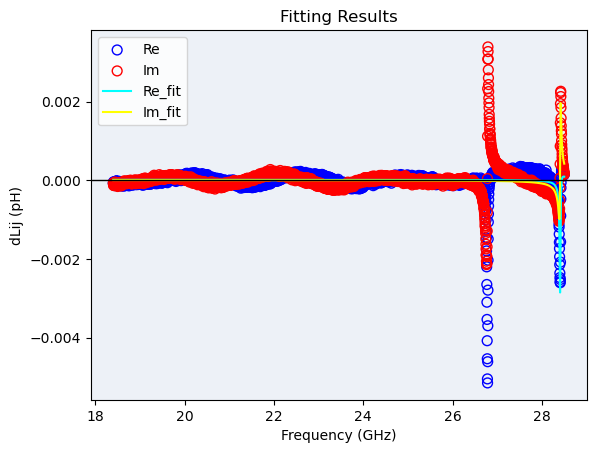


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.261e-05      1.311e-06         U        No
Ai                    -3.669e-05      1.311e-06         U        No
fo                       28.4092      6.097e-04       GHz        No
df                        0.0131      6.097e-04       GHz        No
re0                    1.489e-05      4.301e-06         U        No
im0                    8.227e-06      4.301e-06         U        No
----------------------------------------------------------------------
Guide freq.=28.077331568055016
7


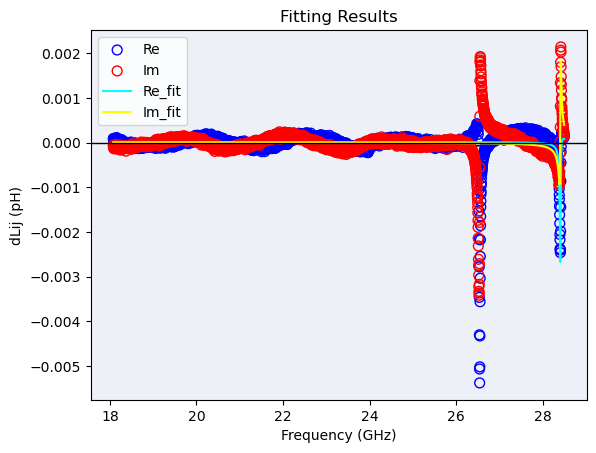


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.168e-05      1.326e-06         U        No
Ai                    -3.455e-05      1.326e-06         U        No
fo                       28.4092      6.592e-04       GHz        No
df                        0.0132      6.592e-04       GHz        No
re0                    1.324e-05      4.268e-06         U        No
im0                    6.114e-07      4.268e-06         U        No
----------------------------------------------------------------------
Guide freq.=27.751593014497132
8


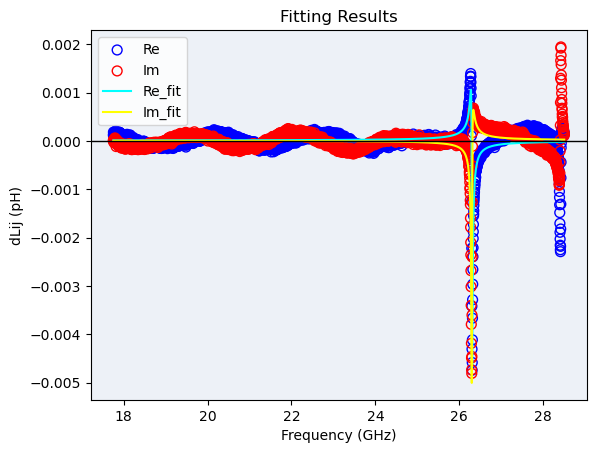


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -5.195e-05      7.536e-07         U        No
Ai                    -4.210e-05      7.536e-07         U        No
fo                       26.2994      1.865e-04       GHz        No
df                        0.0117      1.865e-04       GHz        No
re0                    5.856e-06      2.654e-06         U        No
im0                    9.859e-06      2.654e-06         U        No
----------------------------------------------------------------------
Guide freq.=27.37009770966222
9


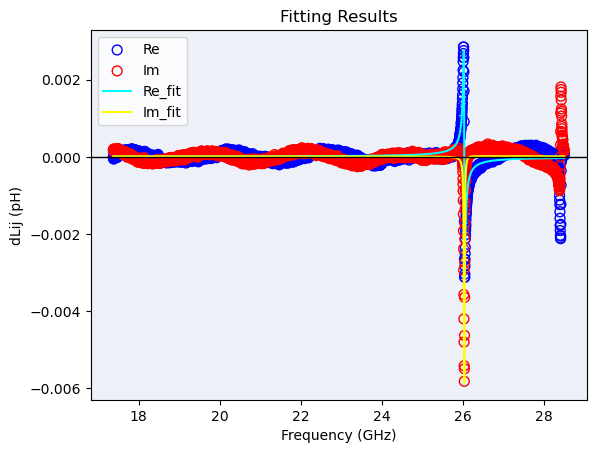


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.786e-05      7.153e-07         U        No
Ai                    -3.893e-06      7.153e-07         U        No
fo                       26.0329      1.710e-04       GHz        No
df                        0.0115      1.710e-04       GHz        No
re0                   -2.087e-06      2.498e-06         U        No
im0                    1.253e-05      2.498e-06         U        No
----------------------------------------------------------------------
Guide freq.=27.005374505316396
10


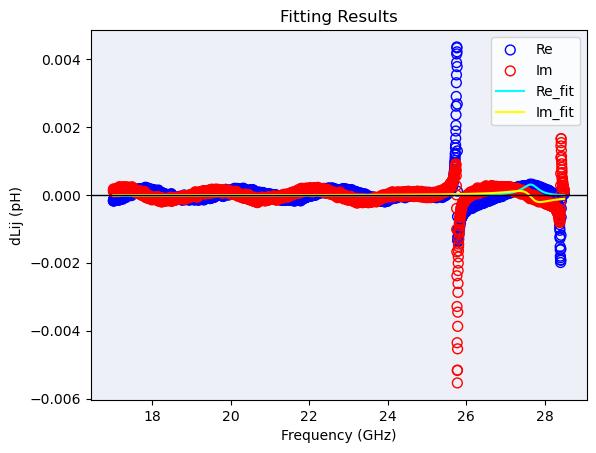


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.495e-05      7.489e-06         U        No
Ai                     8.238e-05      7.489e-06         U        No
fo                       27.6661         0.0290       GHz        No
df                        0.2559         0.0290       GHz        No
re0                   -2.028e-05      4.899e-06         U        No
im0                   -1.897e-05      4.899e-06         U        No
----------------------------------------------------------------------
Guide freq.=26.62877579061711
11


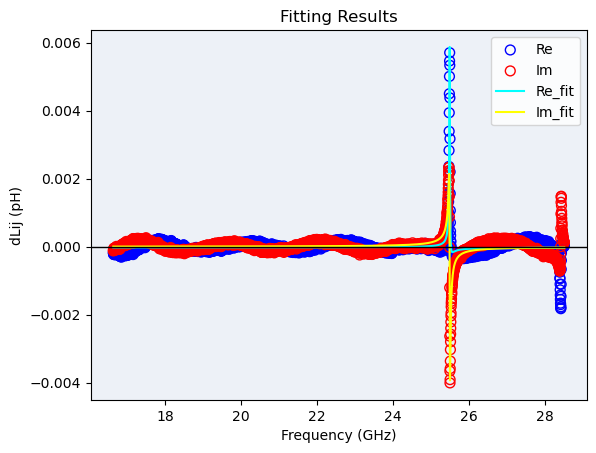


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.991e-05      6.787e-07         U        No
Ai                     6.472e-05      6.787e-07         U        No
fo                       25.4851      1.575e-04       GHz        No
df                        0.0111      1.575e-04       GHz        No
re0                   -2.402e-05      2.336e-06         U        No
im0                   -3.607e-06      2.336e-06         U        No
----------------------------------------------------------------------
Guide freq.=26.224359875271563
12


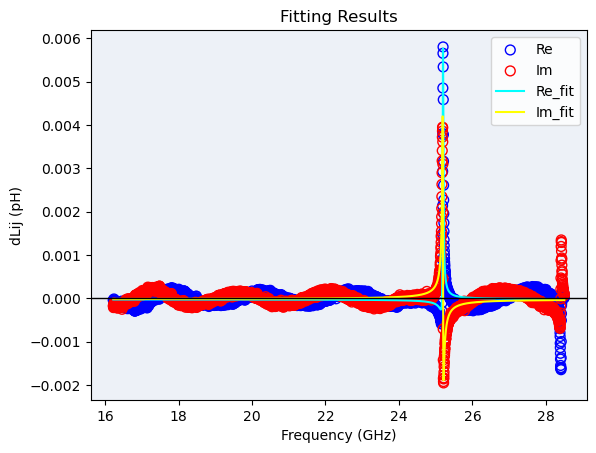


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.587e-05      6.630e-07         U        No
Ai                     6.222e-05      6.630e-07         U        No
fo                       25.1979      1.534e-04       GHz        No
df                        0.0110      1.534e-04       GHz        No
re0                   -2.172e-05      2.253e-06         U        No
im0                   -1.872e-05      2.253e-06         U        No
----------------------------------------------------------------------
Guide freq.=25.842070904059117
13


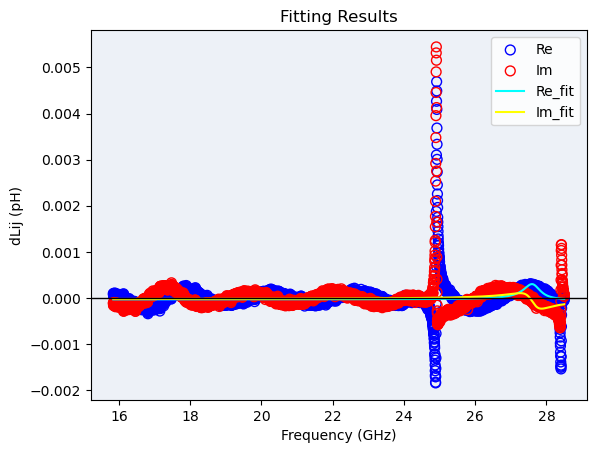


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.003e-05      7.754e-06         U        No
Ai                     9.693e-05      7.754e-06         U        No
fo                       27.6238         0.0289       GHz        No
df                        0.2936         0.0289       GHz        No
re0                   -3.197e-05      4.469e-06         U        No
im0                   -2.881e-05      4.469e-06         U        No
----------------------------------------------------------------------
Guide freq.=25.399243442685695
14


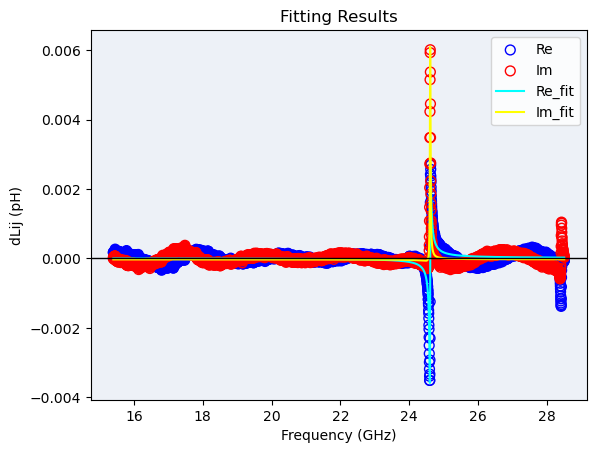


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.600e-05      6.226e-07         U        No
Ai                    -1.057e-05      6.226e-07         U        No
fo                       24.6054      1.414e-04       GHz        No
df                        0.0108      1.414e-04       GHz        No
re0                    5.023e-06      2.077e-06         U        No
im0                   -2.915e-05      2.077e-06         U        No
----------------------------------------------------------------------
Guide freq.=24.981720987504755
15


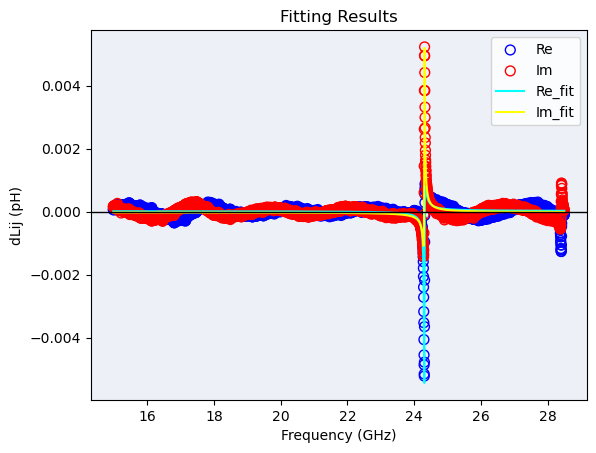


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.475e-05      6.241e-07         U        No
Ai                    -5.081e-05      6.241e-07         U        No
fo                       24.3085      1.398e-04       GHz        No
df                        0.0107      1.398e-04       GHz        No
re0                    1.806e-05      2.050e-06         U        No
im0                   -1.931e-05      2.050e-06         U        No
----------------------------------------------------------------------
Guide freq.=24.557259595228082
16


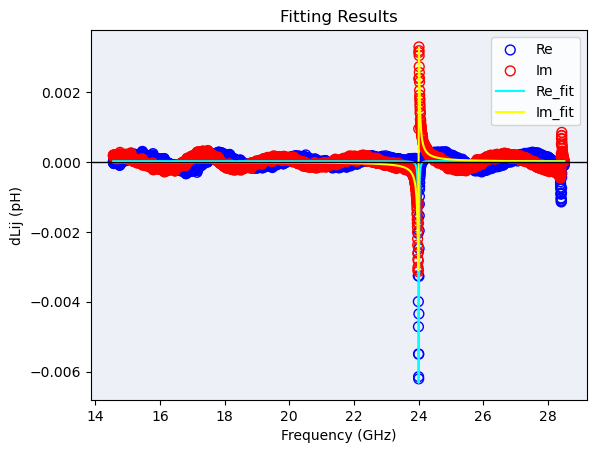


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.642e-06      6.078e-07         U        No
Ai                    -6.946e-05      6.078e-07         U        No
fo                       23.9987      1.342e-04       GHz        No
df                        0.0109      1.342e-04       GHz        No
re0                    2.097e-05      1.955e-06         U        No
im0                   -1.383e-06      1.955e-06         U        No
----------------------------------------------------------------------
Guide freq.=24.12745466918146
17


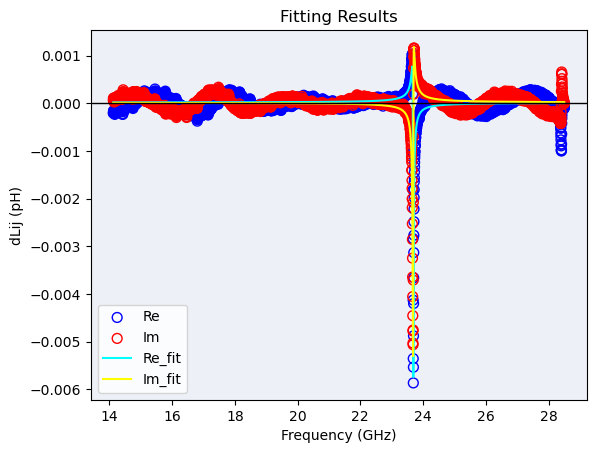


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.542e-05      6.013e-07         U        No
Ai                    -5.435e-05      6.013e-07         U        No
fo                       23.6854      1.303e-04       GHz        No
df                        0.0109      1.303e-04       GHz        No
re0                    1.115e-05      1.904e-06         U        No
im0                    1.222e-05      1.904e-06         U        No
----------------------------------------------------------------------
Guide freq.=23.675907477378463
18


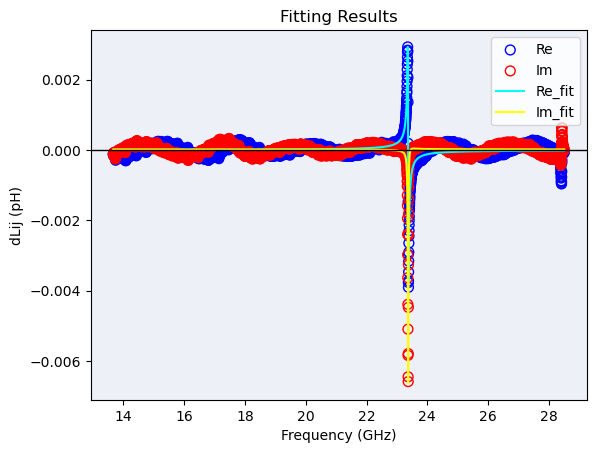


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.432e-05      6.003e-07         U        No
Ai                    -9.173e-06      6.003e-07         U        No
fo                       23.3689      1.268e-04       GHz        No
df                        0.0112      1.268e-04       GHz        No
re0                   -4.553e-06      1.844e-06         U        No
im0                    1.343e-05      1.844e-06         U        No
----------------------------------------------------------------------
Guide freq.=23.22243938496347
19


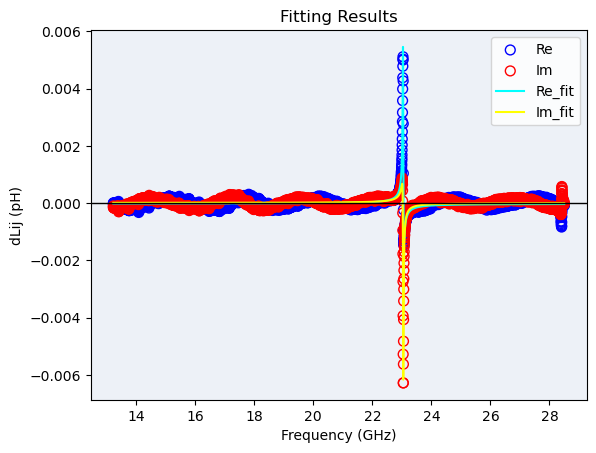


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.087e-05      5.888e-07         U        No
Ai                     4.482e-05      5.888e-07         U        No
fo                       23.0429      1.209e-04       GHz        No
df                        0.0110      1.209e-04       GHz        No
re0                   -1.722e-05      1.799e-06         U        No
im0                    7.938e-06      1.799e-06         U        No
----------------------------------------------------------------------
Guide freq.=22.787196190871903
20


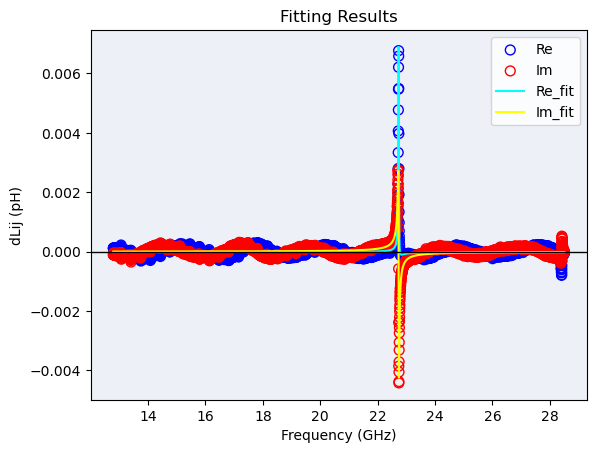


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.695e-05      5.844e-07         U        No
Ai                     7.505e-05      5.844e-07         U        No
fo                       22.7302      1.178e-04       GHz        No
df                        0.0110      1.178e-04       GHz        No
re0                   -1.990e-05      1.761e-06         U        No
im0                   -7.478e-06      1.761e-06         U        No
----------------------------------------------------------------------
Guide freq.=22.353833635466447
21


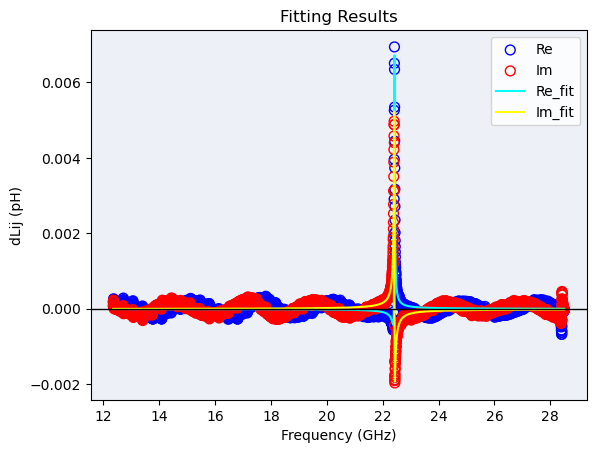


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.639e-05      5.813e-07         U        No
Ai                     6.926e-05      5.813e-07         U        No
fo                       22.4175      1.141e-04       GHz        No
df                        0.0109      1.141e-04       GHz        No
re0                   -1.151e-05      1.737e-06         U        No
im0                   -1.602e-05      1.737e-06         U        No
----------------------------------------------------------------------
Guide freq.=21.906233343283173
22


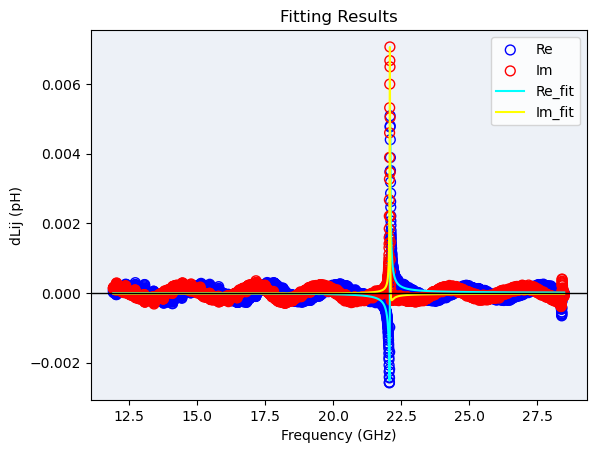


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.570e-05      5.948e-07         U        No
Ai                     2.522e-05      5.948e-07         U        No
fo                       22.0858      1.142e-04       GHz        No
df                        0.0108      1.142e-04       GHz        No
re0                    3.516e-06      1.755e-06         U        No
im0                   -1.760e-05      1.755e-06         U        No
----------------------------------------------------------------------
Guide freq.=21.481814567972723
23


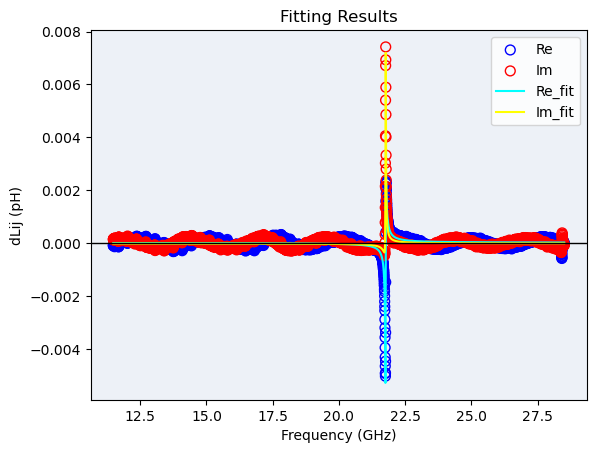


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.484e-05      6.067e-07         U        No
Ai                    -3.406e-05      6.068e-07         U        No
fo                       21.7603      1.133e-04       GHz        No
df                        0.0109      1.133e-04       GHz        No
re0                    1.353e-05      1.766e-06         U        No
im0                   -1.199e-05      1.766e-06         U        No
----------------------------------------------------------------------
Guide freq.=21.06396857229644
24


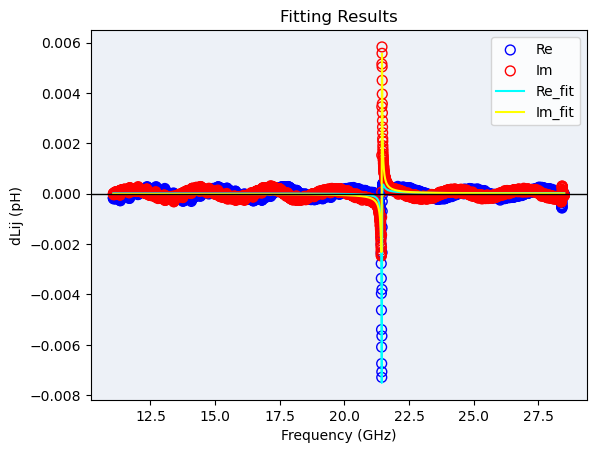


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.406e-05      5.547e-07         U        No
Ai                    -7.502e-05      5.548e-07         U        No
fo                       21.4460      9.935e-05       GHz        No
df                        0.0104      9.935e-05       GHz        No
re0                    1.565e-05      1.628e-06         U        No
im0                   -3.446e-06      1.628e-06         U        No
----------------------------------------------------------------------
Guide freq.=20.636965143361508
25


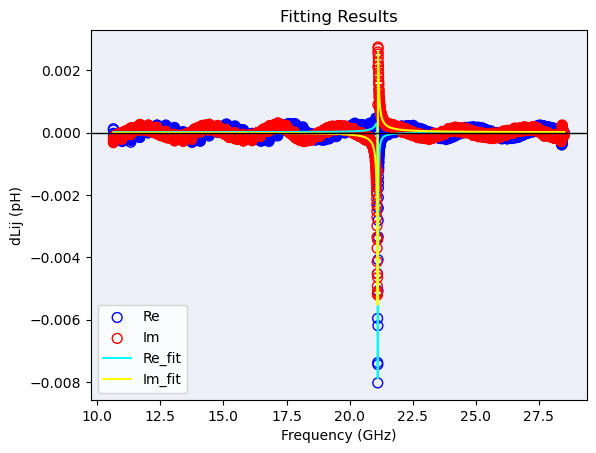


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.085e-05      5.404e-07         U        No
Ai                    -7.887e-05      5.404e-07         U        No
fo                       21.1109      9.305e-05       GHz        No
df                        0.0103      9.305e-05       GHz        No
re0                    1.021e-05      1.576e-06         U        No
im0                    6.195e-06      1.576e-06         U        No
----------------------------------------------------------------------
Guide freq.=20.2359300100558
26


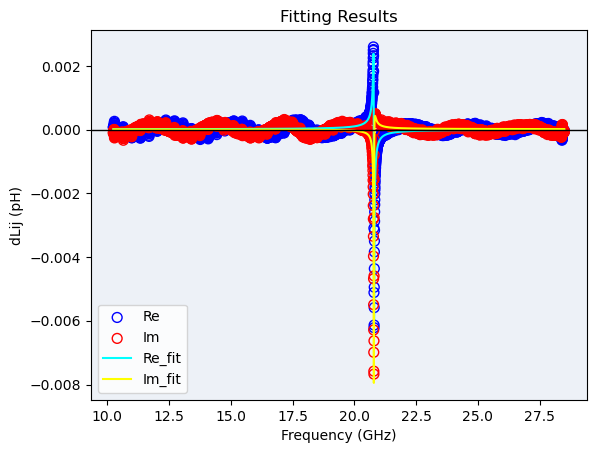


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.702e-05      5.255e-07         U        No
Ai                    -3.720e-05      5.255e-07         U        No
fo                       20.7918      8.822e-05       GHz        No
df                        0.0102      8.822e-05       GHz        No
re0                    3.382e-06      1.527e-06         U        No
im0                    9.771e-06      1.527e-06         U        No
----------------------------------------------------------------------
Guide freq.=19.82817531621641
27


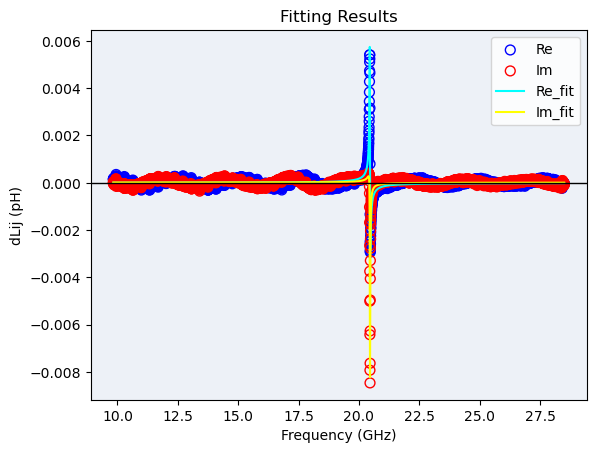


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.150e-05      5.241e-07         U        No
Ai                     3.017e-05      5.241e-07         U        No
fo                       20.4554      8.604e-05       GHz        No
df                        0.0101      8.604e-05       GHz        No
re0                   -5.410e-06      1.511e-06         U        No
im0                    9.624e-06      1.511e-06         U        No
----------------------------------------------------------------------
Guide freq.=19.446728631694484
28


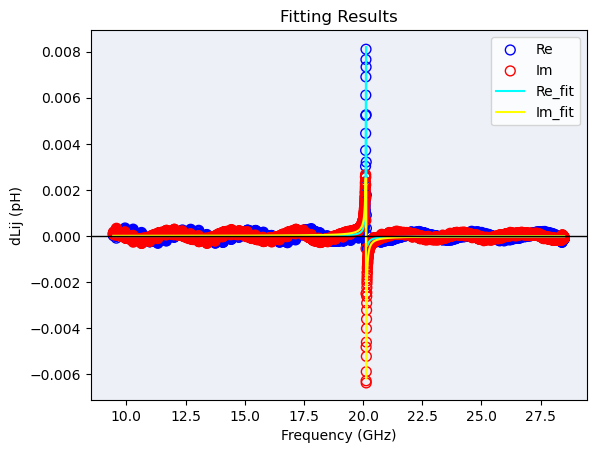


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.645e-05      4.893e-07         U        No
Ai                     7.676e-05      4.893e-07         U        No
fo                       20.1263      7.904e-05       GHz        No
df                        0.0097      7.904e-05       GHz        No
re0                   -1.012e-05      1.424e-06         U        No
im0                    6.783e-07      1.424e-06         U        No
----------------------------------------------------------------------
Guide freq.=19.075193780448945
29


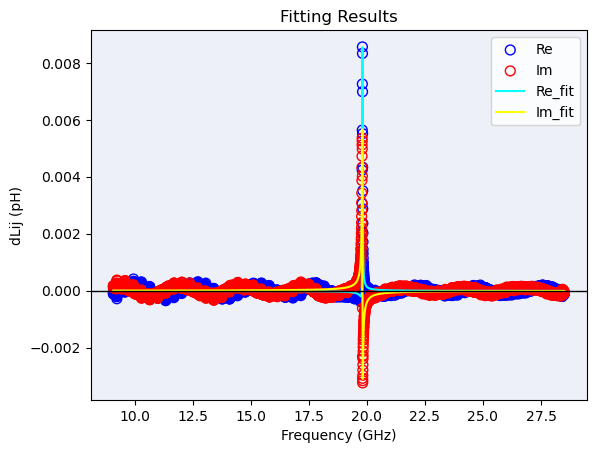


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.452e-05      4.699e-07         U        No
Ai                     7.951e-05      4.699e-07         U        No
fo                       19.8049      7.575e-05       GHz        No
df                        0.0095      7.575e-05       GHz        No
re0                   -8.978e-06      1.370e-06         U        No
im0                   -3.850e-06      1.370e-06         U        No
----------------------------------------------------------------------
Guide freq.=18.698547988812408
30


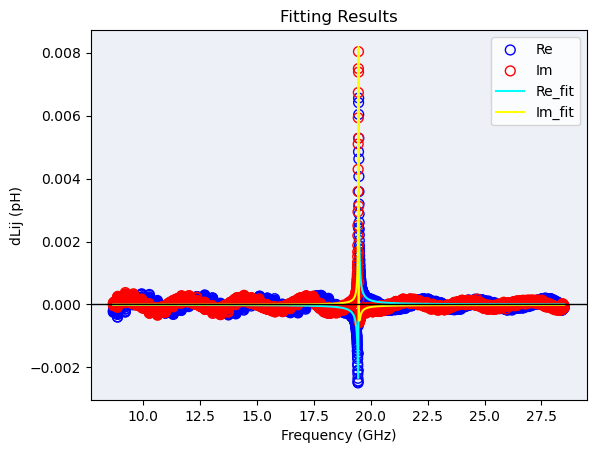


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.365e-05      4.730e-07         U        No
Ai                     3.887e-05      4.730e-07         U        No
fo                       19.4659      7.633e-05       GHz        No
df                        0.0095      7.633e-05       GHz        No
re0                   -4.246e-06      1.365e-06         U        No
im0                   -1.083e-05      1.365e-06         U        No
----------------------------------------------------------------------
Guide freq.=18.360983762145143
31


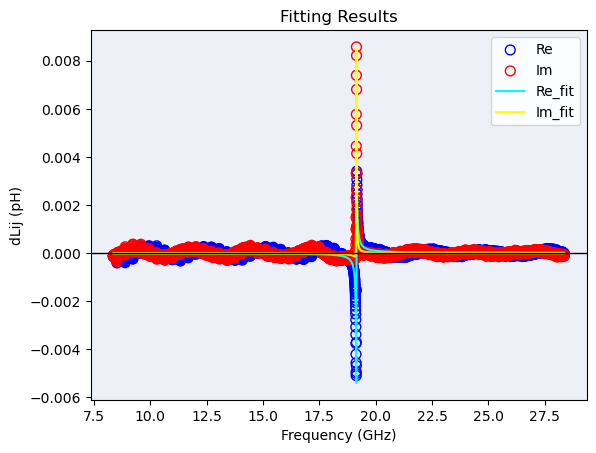


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     8.081e-05      4.561e-07         U        No
Ai                    -2.055e-05      4.561e-07         U        No
fo                       19.1441      7.429e-05       GHz        No
df                        0.0096      7.429e-05       GHz        No
re0                    2.201e-06      1.303e-06         U        No
im0                   -1.175e-05      1.303e-06         U        No
----------------------------------------------------------------------
Guide freq.=18.00311008221084
32


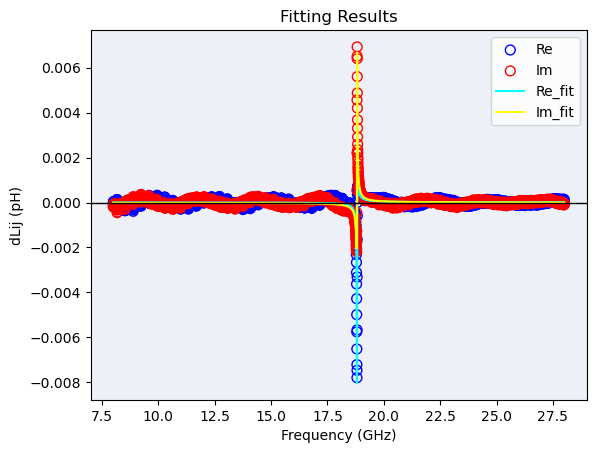


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.547e-05      4.764e-07         U        No
Ai                    -7.178e-05      4.764e-07         U        No
fo                       18.8117      7.714e-05       GHz        No
df                        0.0097      7.714e-05       GHz        No
re0                    9.654e-06      1.352e-06         U        No
im0                   -6.844e-06      1.352e-06         U        No
----------------------------------------------------------------------
Guide freq.=17.667543385136085
33


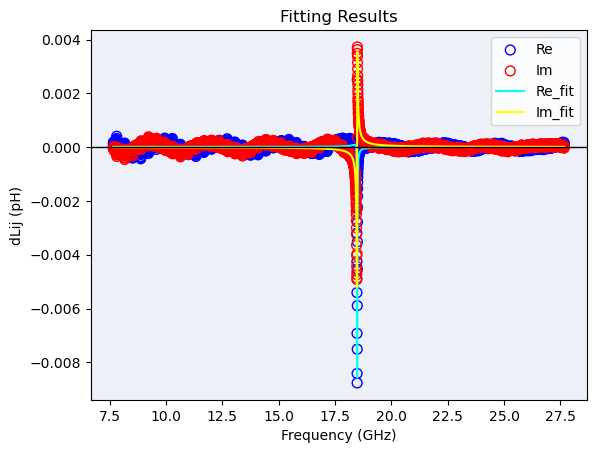


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.630e-05      4.468e-07         U        No
Ai                    -8.263e-05      4.468e-07         U        No
fo                       18.4790      7.181e-05       GHz        No
df                        0.0096      7.181e-05       GHz        No
re0                    9.334e-06      1.278e-06         U        No
im0                    1.441e-06      1.278e-06         U        No
----------------------------------------------------------------------
Guide freq.=17.32520246835506
34


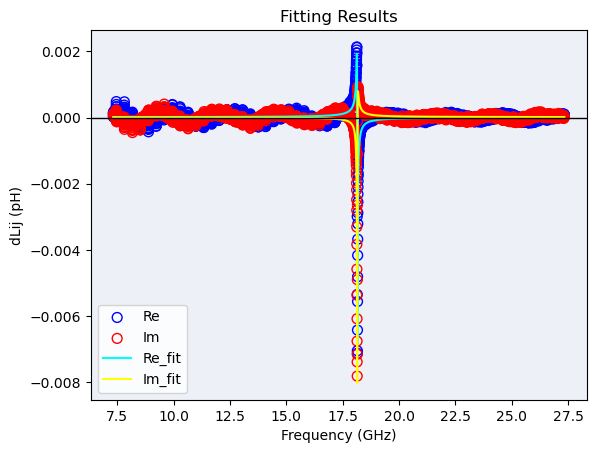


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.957e-05      4.244e-07         U        No
Ai                    -4.794e-05      4.244e-07         U        No
fo                       18.1447      6.730e-05       GHz        No
df                        0.0095      6.730e-05       GHz        No
re0                    6.180e-06      1.221e-06         U        No
im0                    9.463e-06      1.221e-06         U        No
----------------------------------------------------------------------
Guide freq.=16.98893114079488
35


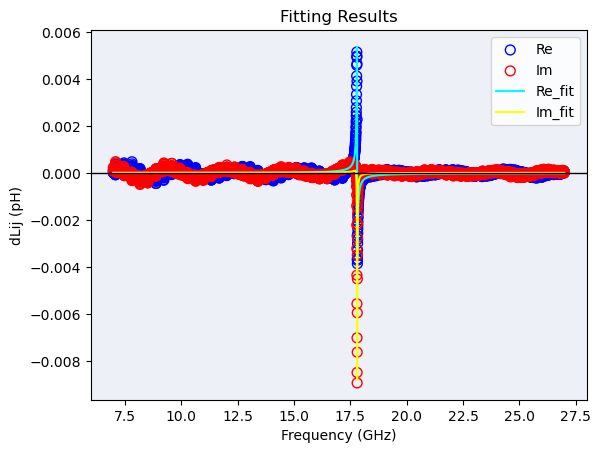


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.159e-05      4.536e-07         U        No
Ai                     1.659e-05      4.536e-07         U        No
fo                       17.8013      7.101e-05       GHz        No
df                        0.0092      7.101e-05       GHz        No
re0                   -4.464e-06      1.323e-06         U        No
im0                    1.149e-05      1.323e-06         U        No
----------------------------------------------------------------------
Guide freq.=16.67052501243224
36


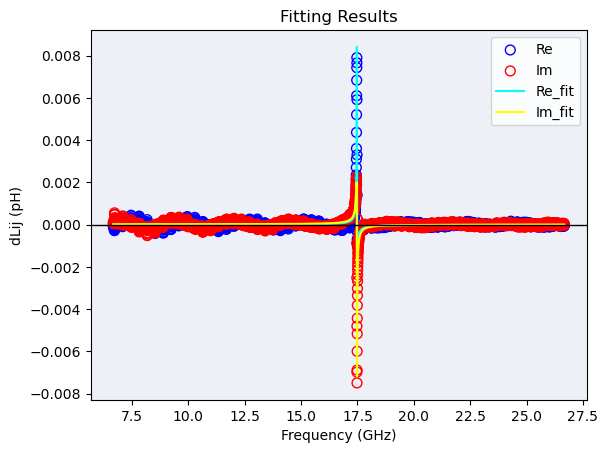


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.807e-05      4.046e-07         U        No
Ai                     6.954e-05      4.046e-07         U        No
fo                       17.4736      6.187e-05       GHz        No
df                        0.0092      6.187e-05       GHz        No
re0                   -8.552e-06      1.185e-06         U        No
im0                    5.711e-06      1.185e-06         U        No
----------------------------------------------------------------------
Guide freq.=16.368251792503223
37


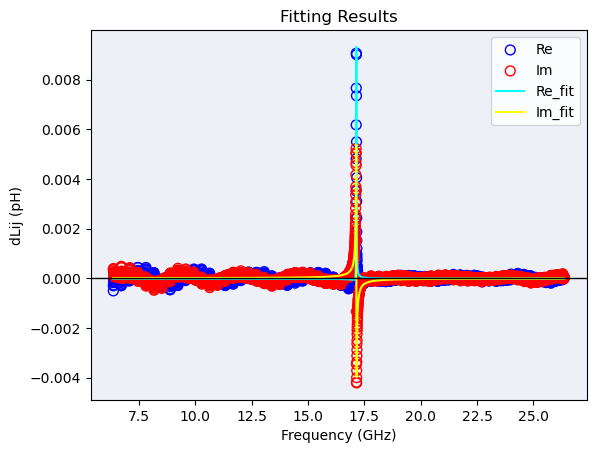


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.197e-05      4.025e-07         U        No
Ai                     8.101e-05      4.025e-07         U        No
fo                       17.1458      6.049e-05       GHz        No
df                        0.0087      6.049e-05       GHz        No
re0                   -1.563e-05      1.208e-06         U        No
im0                   -2.055e-06      1.208e-06         U        No
----------------------------------------------------------------------
Guide freq.=16.04156596413563
38


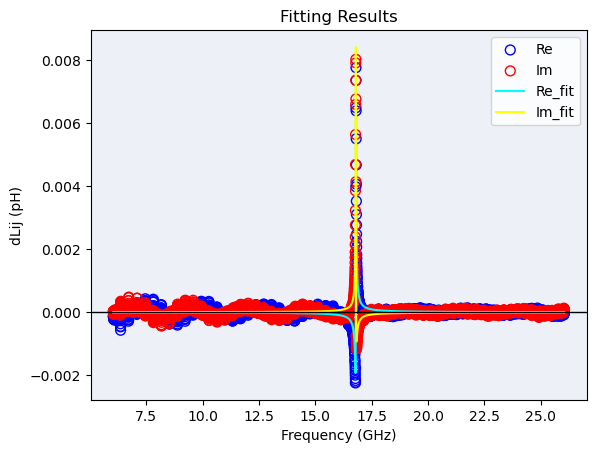


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.570e-05      3.776e-07         U        No
Ai                     4.858e-05      3.776e-07         U        No
fo                       16.8001      5.601e-05       GHz        No
df                        0.0086      5.601e-05       GHz        No
re0                   -1.095e-05      1.142e-06         U        No
im0                   -9.861e-06      1.142e-06         U        No
----------------------------------------------------------------------
Guide freq.=15.71551259054199
39


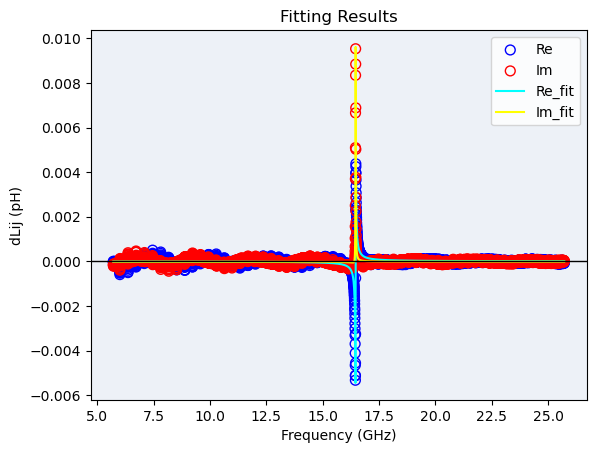


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     8.074e-05      3.619e-07         U        No
Ai                    -1.031e-05      3.619e-07         U        No
fo                       16.4620      5.287e-05       GHz        No
df                        0.0084      5.287e-05       GHz        No
re0                   -6.857e-07      1.105e-06         U        No
im0                   -1.280e-05      1.105e-06         U        No
----------------------------------------------------------------------
Guide freq.=15.401947438650948
40


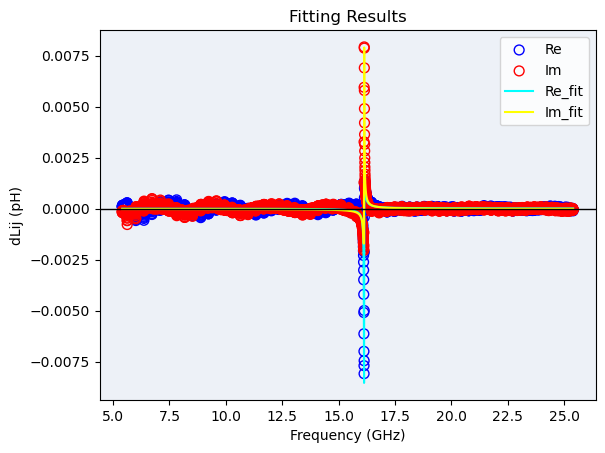


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.148e-05      3.694e-07         U        No
Ai                    -6.025e-05      3.694e-07         U        No
fo                       16.1324      5.371e-05       GHz        No
df                        0.0082      5.371e-05       GHz        No
re0                    7.423e-06      1.146e-06         U        No
im0                   -1.261e-05      1.146e-06         U        No
----------------------------------------------------------------------
Guide freq.=15.086873937411209
41


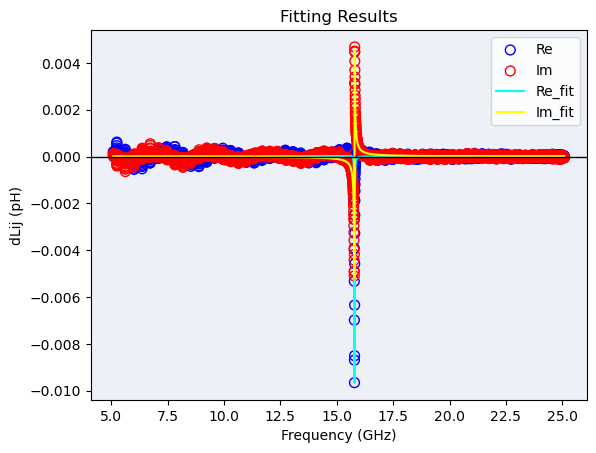


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.985e-06      3.440e-07         U        No
Ai                    -7.898e-05      3.440e-07         U        No
fo                       15.7843      4.984e-05       GHz        No
df                        0.0081      4.984e-05       GHz        No
re0                    1.297e-05      1.070e-06         U        No
im0                   -2.881e-06      1.070e-06         U        No
----------------------------------------------------------------------
Guide freq.=14.756231041429034
42


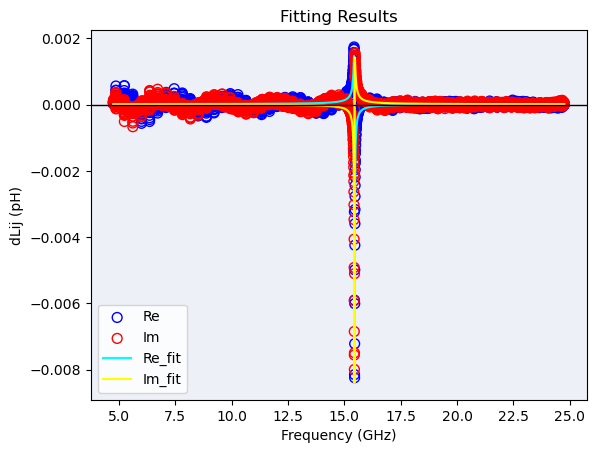


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -5.634e-05      3.447e-07         U        No
Ai                    -5.563e-05      3.447e-07         U        No
fo                       15.4527      4.955e-05       GHz        No
df                        0.0081      4.955e-05       GHz        No
re0                    1.193e-05      1.076e-06         U        No
im0                    7.795e-06      1.076e-06         U        No
----------------------------------------------------------------------
Guide freq.=14.42245522609564
43


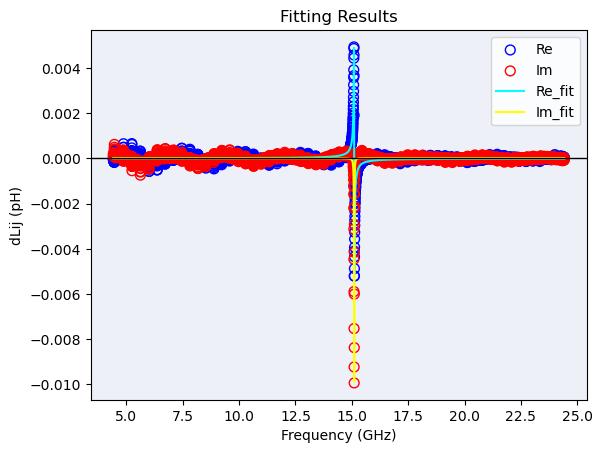


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.051e-05      3.824e-07         U        No
Ai                    -1.989e-06      3.824e-07         U        No
fo                       15.1038      5.358e-05       GHz        No
df                        0.0080      5.358e-05       GHz        No
re0                    3.146e-06      1.199e-06         U        No
im0                    1.160e-05      1.199e-06         U        No
----------------------------------------------------------------------
Guide freq.=14.098707571304159
44


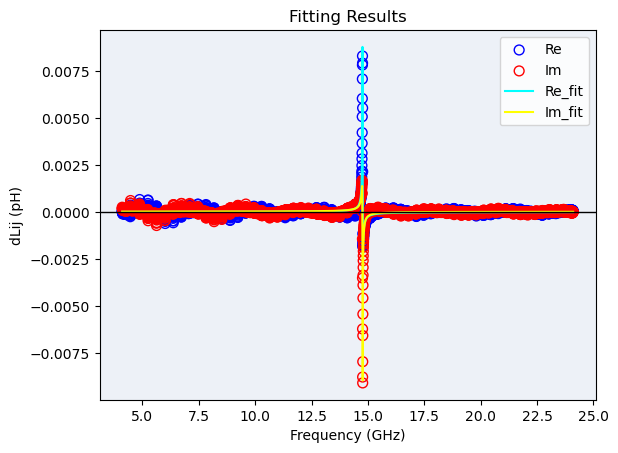


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.160e-05      3.860e-07         U        No
Ai                     5.585e-05      3.860e-07         U        No
fo                       14.7616      5.177e-05       GHz        No
df                        0.0079      5.177e-05       GHz        No
re0                   -6.526e-06      1.217e-06         U        No
im0                    1.272e-05      1.217e-06         U        No
----------------------------------------------------------------------
Guide freq.=13.771569580717811
45


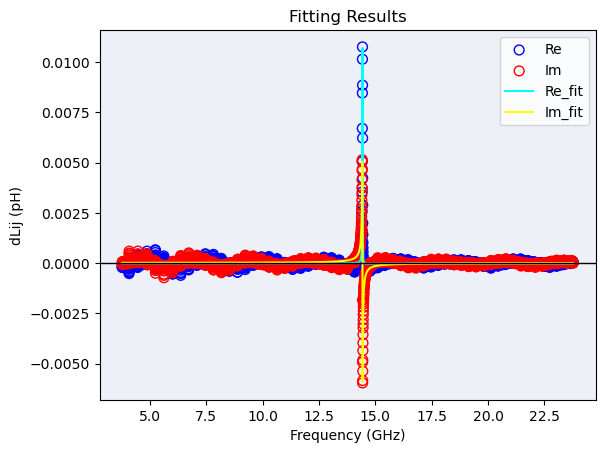


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.511e-06      4.203e-07         U        No
Ai                     8.603e-05      4.203e-07         U        No
fo                       14.4290      5.385e-05       GHz        No
df                        0.0078      5.385e-05       GHz        No
re0                   -1.623e-05      1.331e-06         U        No
im0                    4.492e-06      1.331e-06         U        No
----------------------------------------------------------------------
Guide freq.=13.427289943053934
46


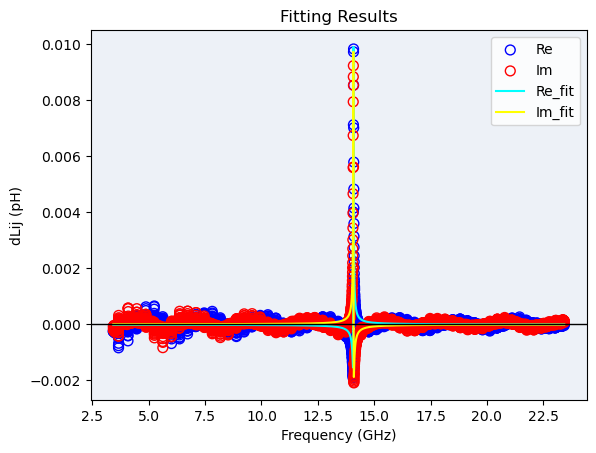


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.074e-05      4.293e-07         U        No
Ai                     6.623e-05      4.293e-07         U        No
fo                       14.0781      5.211e-05       GHz        No
df                        0.0077      5.211e-05       GHz        No
re0                   -1.593e-05      1.368e-06         U        No
im0                   -8.316e-06      1.368e-06         U        No
----------------------------------------------------------------------
Guide freq.=13.09371354212717
47


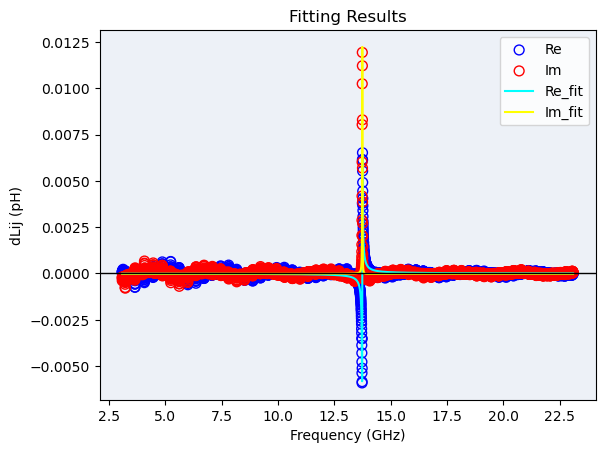


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     9.265e-05      3.953e-07         U        No
Ai                     4.354e-06      3.953e-07         U        No
fo                       13.7445      4.552e-05       GHz        No
df                        0.0076      4.552e-05       GHz        No
re0                   -4.861e-06      1.274e-06         U        No
im0                   -1.666e-05      1.274e-06         U        No
----------------------------------------------------------------------
Guide freq.=12.75761188188673
48


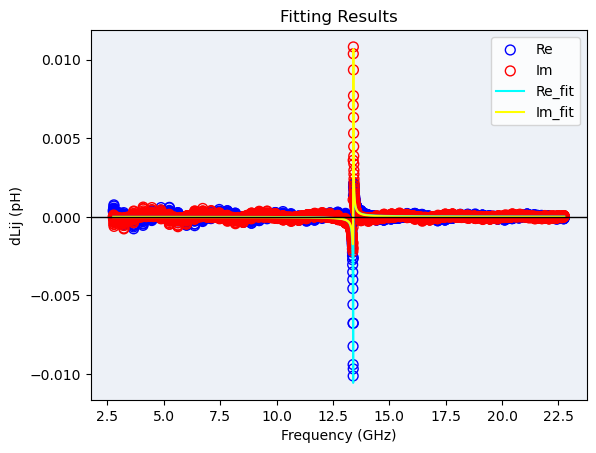


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.869e-05      3.816e-07         U        No
Ai                    -6.483e-05      3.816e-07         U        No
fo                       13.4009      4.248e-05       GHz        No
df                        0.0074      4.248e-05       GHz        No
re0                    7.950e-06      1.239e-06         U        No
im0                   -1.448e-05      1.239e-06         U        No
----------------------------------------------------------------------
Guide freq.=12.405492436971613
49


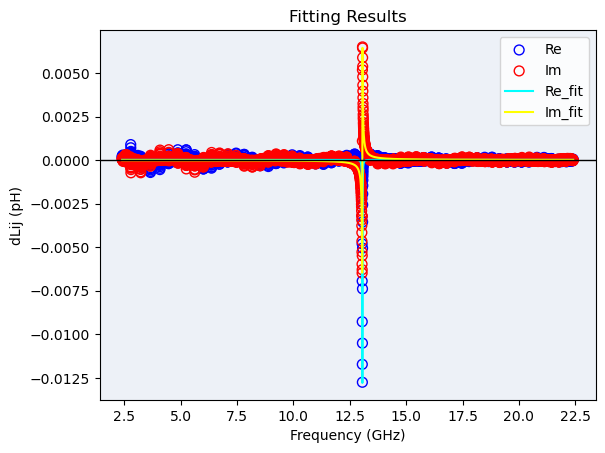


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.283e-07      3.445e-07         U        No
Ai                    -9.609e-05      3.445e-07         U        No
fo                       13.0572      3.753e-05       GHz        No
df                        0.0074      3.753e-05       GHz        No
re0                    1.553e-05      1.121e-06         U        No
im0                   -2.265e-06      1.121e-06         U        No
----------------------------------------------------------------------
Guide freq.=12.066279828608772
50


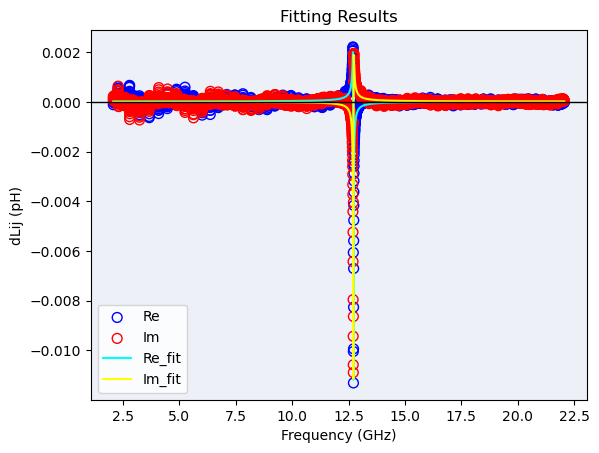


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.936e-05      3.287e-07         U        No
Ai                    -6.776e-05      3.287e-07         U        No
fo                       12.7128      3.506e-05       GHz        No
df                        0.0073      3.506e-05       GHz        No
re0                    1.127e-05      1.076e-06         U        No
im0                    8.020e-06      1.076e-06         U        No
----------------------------------------------------------------------
Guide freq.=11.712567708247647
51


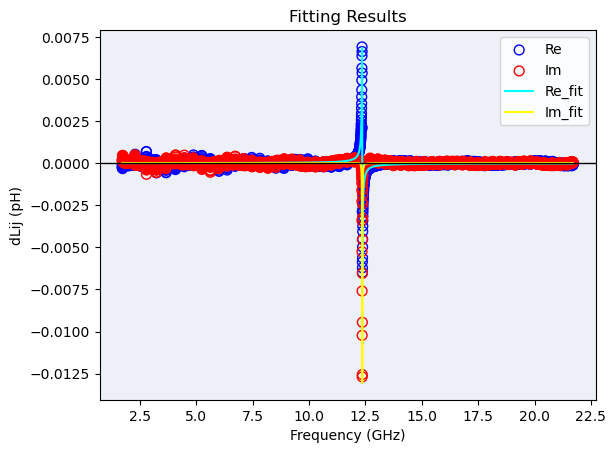


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -9.631e-05      3.276e-07         U        No
Ai                     3.458e-06      3.276e-07         U        No
fo                       12.3588      3.486e-05       GHz        No
df                        0.0073      3.486e-05       GHz        No
re0                   -1.131e-06      1.077e-06         U        No
im0                    1.447e-05      1.077e-06         U        No
----------------------------------------------------------------------
Guide freq.=11.373473598552057
52


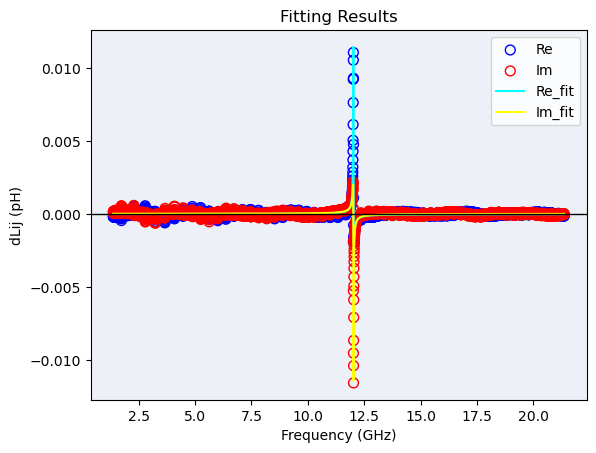


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.828e-05      3.588e-07         U        No
Ai                     6.929e-05      3.588e-07         U        No
fo                       12.0217      3.781e-05       GHz        No
df                        0.0073      3.781e-05       GHz        No
re0                   -1.334e-05      1.180e-06         U        No
im0                    1.203e-05      1.180e-06         U        No
----------------------------------------------------------------------
Guide freq.=11.035591004124779
53


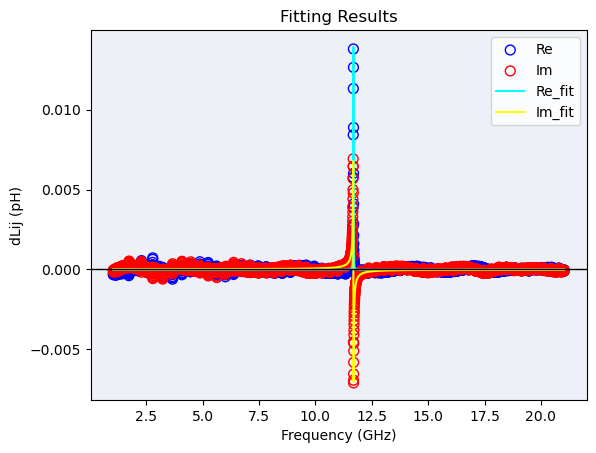


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.580e-06      3.862e-07         U        No
Ai                     9.822e-05      3.862e-07         U        No
fo                       11.6836      3.900e-05       GHz        No
df                        0.0070      3.900e-05       GHz        No
re0                   -1.845e-05      1.291e-06         U        No
im0                    2.058e-06      1.291e-06         U        No
----------------------------------------------------------------------
Guide freq.=10.699553918702316
54


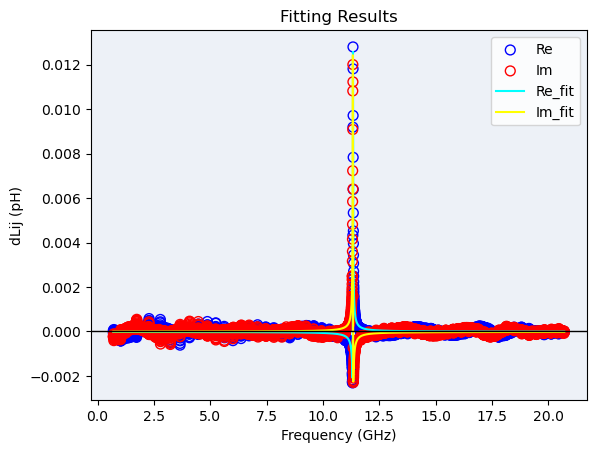


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.912e-05      3.932e-07         U        No
Ai                     7.126e-05      3.932e-07         U        No
fo                       11.3283      3.764e-05       GHz        No
df                        0.0067      3.764e-05       GHz        No
re0                   -1.470e-05      1.343e-06         U        No
im0                   -1.259e-05      1.343e-06         U        No
----------------------------------------------------------------------
Guide freq.=10.351988012534727
55


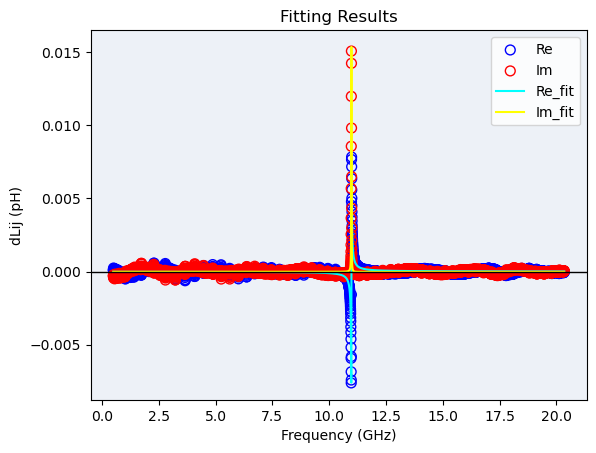


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.018e-04      4.277e-07         U        No
Ai                     2.170e-06      4.277e-07         U        No
fo                       10.9811      3.890e-05       GHz        No
df                        0.0066      3.890e-05       GHz        No
re0                   -6.458e-06      1.485e-06         U        No
im0                   -1.946e-05      1.485e-06         U        No
----------------------------------------------------------------------
Guide freq.=10.020973282407574
56


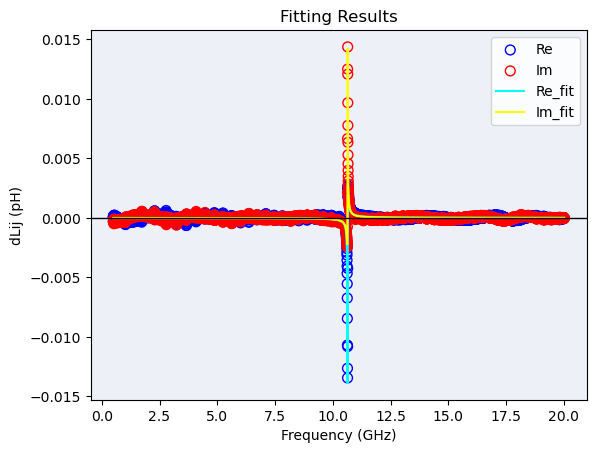


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.771e-05      4.288e-07         U        No
Ai                    -7.199e-05      4.288e-07         U        No
fo                       10.6413      3.660e-05       GHz        No
df                        0.0064      3.660e-05       GHz        No
re0                    6.375e-06      1.520e-06         U        No
im0                   -1.349e-05      1.520e-06         U        No
----------------------------------------------------------------------
Guide freq.=9.678943286151835
57


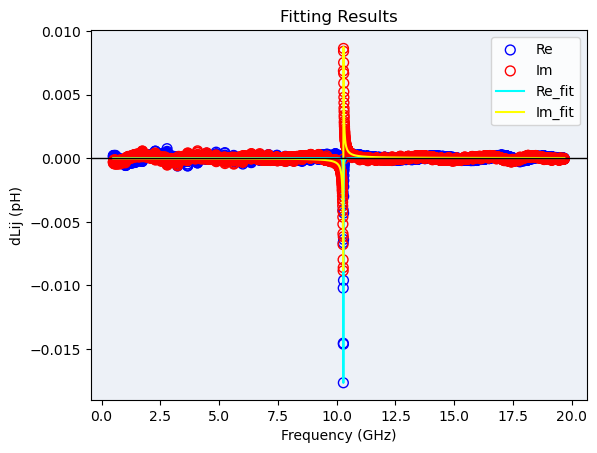


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.848e-07      4.307e-07         U        No
Ai                    -1.100e-04      4.307e-07         U        No
fo                       10.2831      3.444e-05       GHz        No
df                        0.0062      3.444e-05       GHz        No
re0                    1.334e-05      1.561e-06         U        No
im0                   -9.287e-07      1.561e-06         U        No
----------------------------------------------------------------------
Guide freq.=9.352992601534071
58


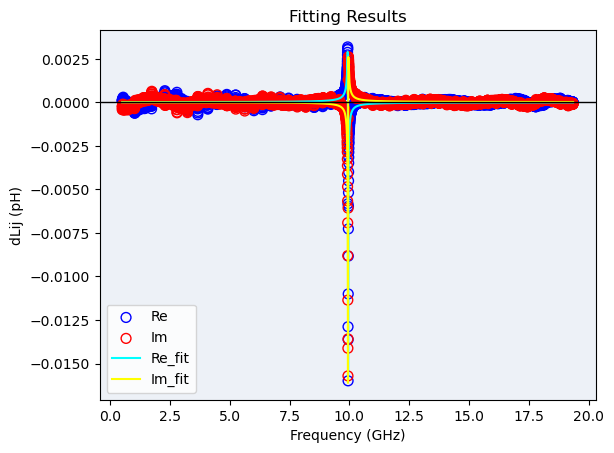


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.261e-05      4.324e-07         U        No
Ai                    -7.909e-05      4.324e-07         U        No
fo                        9.9415      3.255e-05       GHz        No
df                        0.0061      3.255e-05       GHz        No
re0                    8.483e-06      1.598e-06         U        No
im0                    1.564e-05      1.598e-06         U        No
----------------------------------------------------------------------
Guide freq.=9.02884126067149
59


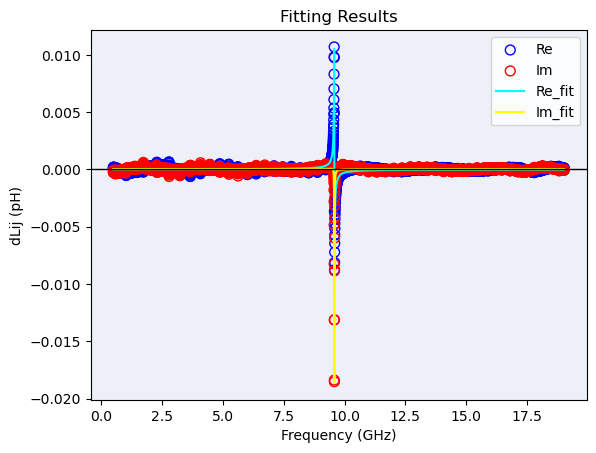


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.166e-04      4.136e-07         U        No
Ai                     1.097e-05      4.136e-07         U        No
fo                        9.5814      2.982e-05       GHz        No
df                        0.0060      2.982e-05       GHz        No
re0                   -4.334e-06      1.557e-06         U        No
im0                    2.214e-05      1.557e-06         U        No
----------------------------------------------------------------------
Guide freq.=8.692211062380613
60


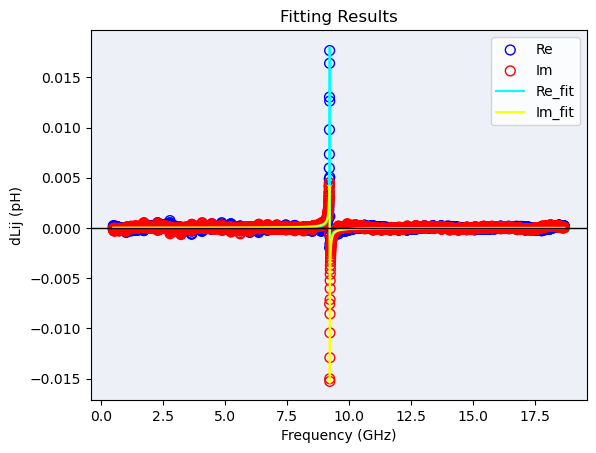


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.909e-05      3.959e-07         U        No
Ai                     9.568e-05      3.959e-07         U        No
fo                        9.2289      2.782e-05       GHz        No
df                        0.0059      2.782e-05       GHz        No
re0                   -1.773e-05      1.518e-06         U        No
im0                    1.631e-05      1.518e-06         U        No
----------------------------------------------------------------------
Guide freq.=8.368923511881604
61


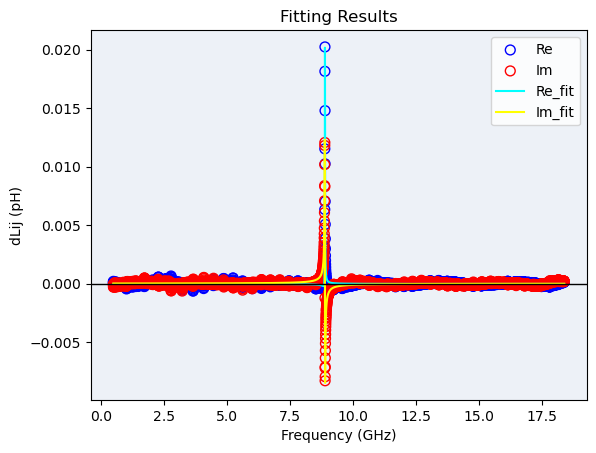


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.162e-05      3.954e-07         U        No
Ai                     1.146e-04      3.954e-07         U        No
fo                        8.8846      2.680e-05       GHz        No
df                        0.0056      2.680e-05       GHz        No
re0                   -2.478e-05      1.567e-06         U        No
im0                    1.080e-06      1.567e-06         U        No
----------------------------------------------------------------------
Guide freq.=8.030644516548588
62


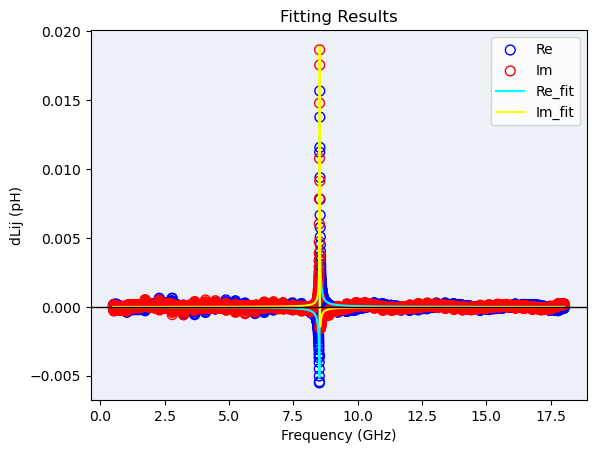


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     9.954e-05      3.626e-07         U        No
Ai                     5.816e-05      3.626e-07         U        No
fo                        8.5218      2.450e-05       GHz        No
df                        0.0055      2.450e-05       GHz        No
re0                   -1.681e-05      1.461e-06         U        No
im0                   -1.778e-05      1.461e-06         U        No
----------------------------------------------------------------------
Guide freq.=7.702978614459274
63


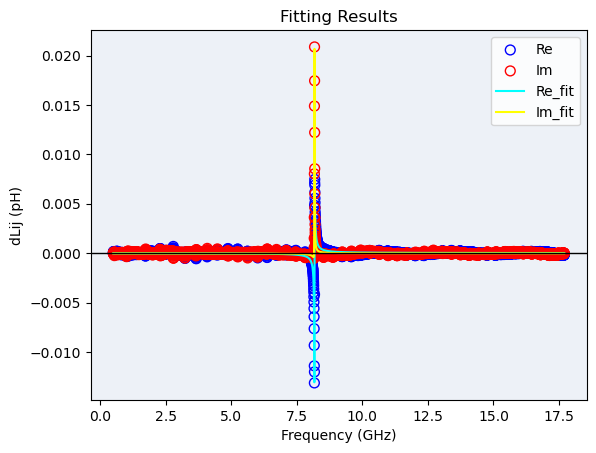


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.101e-04      3.457e-07         U        No
Ai                    -3.004e-05      3.457e-07         U        No
fo                        8.1745      2.307e-05       GHz        No
df                        0.0054      2.307e-05       GHz        No
re0                    2.587e-06      1.422e-06         U        No
im0                   -2.227e-05      1.422e-06         U        No
----------------------------------------------------------------------
Guide freq.=7.370982911351772
64


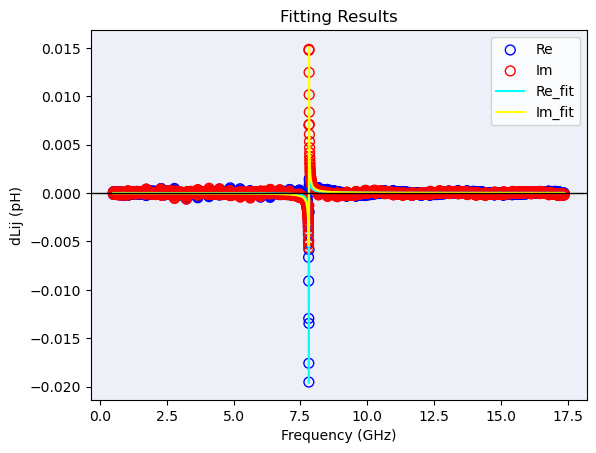


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.658e-05      3.452e-07         U        No
Ai                    -1.007e-04      3.452e-07         U        No
fo                        7.8174      2.309e-05       GHz        No
df                        0.0055      2.309e-05       GHz        No
re0                    2.126e-05      1.424e-06         U        No
im0                   -9.132e-06      1.424e-06         U        No
----------------------------------------------------------------------
Guide freq.=7.033269179297551
65


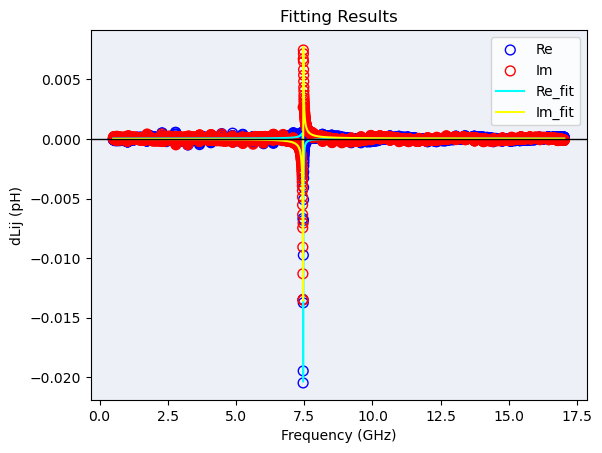


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.361e-05      3.485e-07         U        No
Ai                    -1.134e-04      3.485e-07         U        No
fo                        7.4583      2.271e-05       GHz        No
df                        0.0055      2.271e-05       GHz        No
re0                    2.744e-05      1.453e-06         U        No
im0                    9.016e-06      1.453e-06         U        No
----------------------------------------------------------------------
Guide freq.=6.674102327785588
66


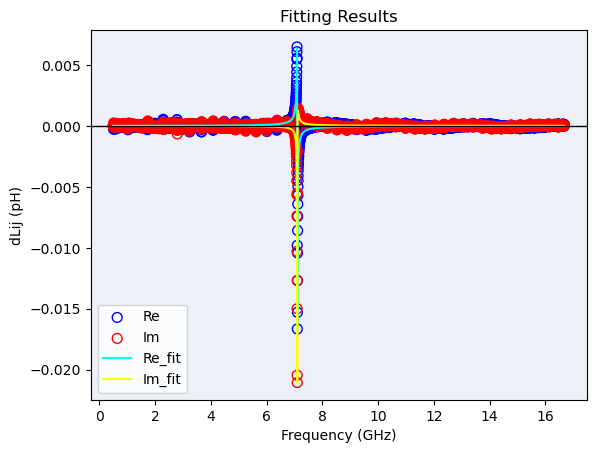


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.104e-04      3.640e-07         U        No
Ai                    -5.610e-05      3.640e-07         U        No
fo                        7.0970      2.213e-05       GHz        No
df                        0.0053      2.213e-05       GHz        No
re0                    1.626e-05      1.553e-06         U        No
im0                    3.061e-05      1.553e-06         U        No
----------------------------------------------------------------------
Guide freq.=6.306399144802303
67


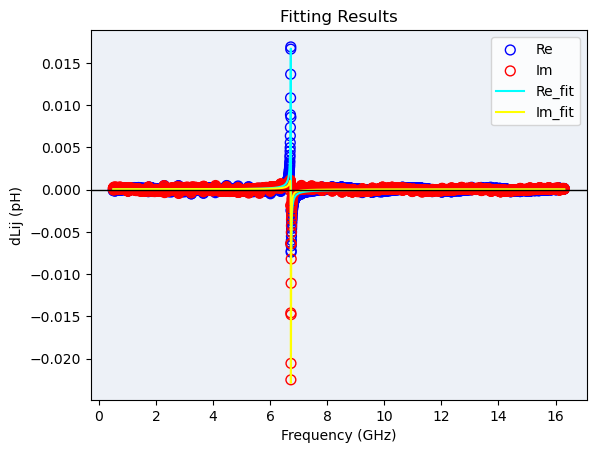


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.207e-04      4.158e-07         U        No
Ai                     5.215e-05      4.158e-07         U        No
fo                        6.7242      2.395e-05       GHz        No
df                        0.0054      2.395e-05       GHz        No
re0                   -4.870e-06      1.790e-06         U        No
im0                    3.519e-05      1.790e-06         U        No
----------------------------------------------------------------------
Guide freq.=5.944873206619547
68


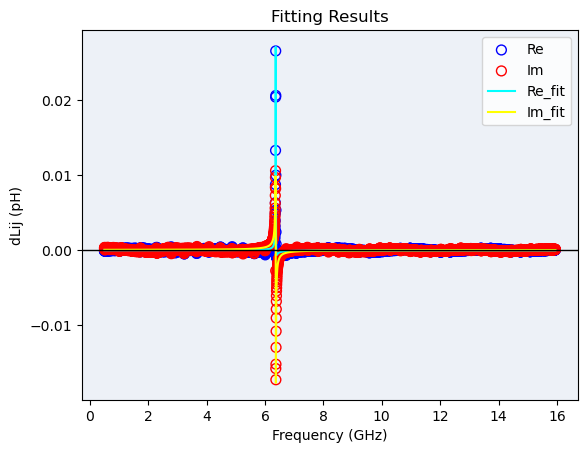


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.074e-05      4.411e-07         U        No
Ai                     1.326e-04      4.411e-07         U        No
fo                        6.3671      2.245e-05       GHz        No
df                        0.0050      2.245e-05       GHz        No
re0                   -2.109e-05      1.990e-06         U        No
im0                    2.186e-05      1.990e-06         U        No
----------------------------------------------------------------------
Guide freq.=5.575034255404078
69


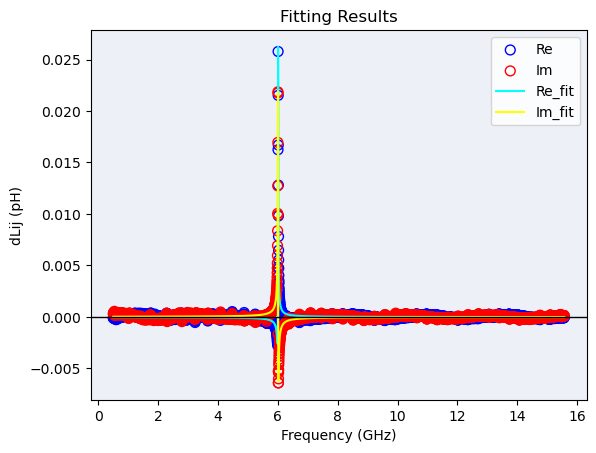


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     8.228e-05      4.990e-07         U        No
Ai                     1.193e-04      4.990e-07         U        No
fo                        6.0065      2.434e-05       GHz        No
df                        0.0050      2.434e-05       GHz        No
re0                   -1.961e-05      2.276e-06         U        No
im0                   -4.687e-06      2.276e-06         U        No
----------------------------------------------------------------------
Guide freq.=5.1816125861488365
70


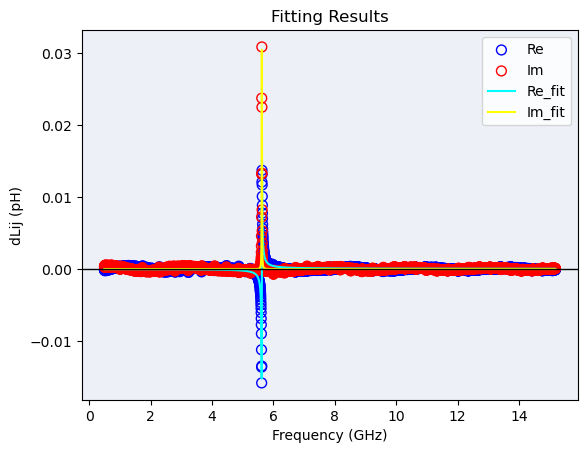


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.495e-04      5.486e-07         U        No
Ai                    -1.588e-06      5.486e-07         U        No
fo                        5.6240      2.545e-05       GHz        No
df                        0.0049      2.545e-05       GHz        No
re0                    5.254e-06      2.559e-06         U        No
im0                   -2.441e-05      2.559e-06         U        No
----------------------------------------------------------------------
Guide freq.=4.7973018830869085
71


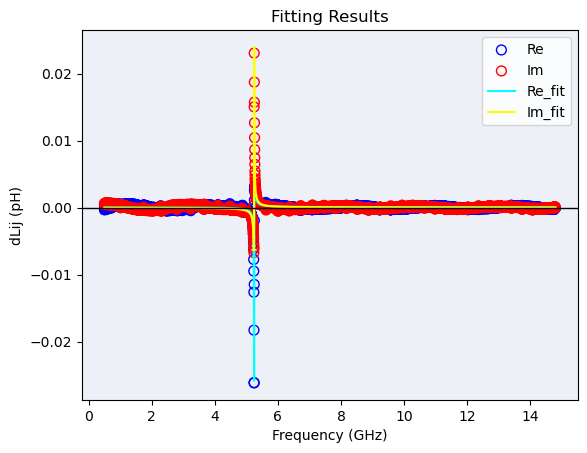


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     8.341e-05      6.056e-07         U        No
Ai                    -1.169e-04      6.056e-07         U        No
fo                        5.2464      2.818e-05       GHz        No
df                        0.0047      2.818e-05       GHz        No
re0                    4.100e-05      2.917e-06         U        No
im0                   -1.797e-05      2.917e-06         U        No
----------------------------------------------------------------------
Guide freq.=4.408157106181238
72


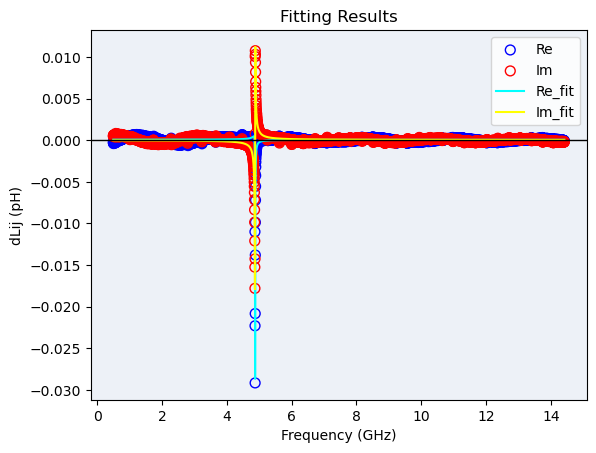


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.346e-05      6.521e-07         U        No
Ai                    -1.380e-04      6.521e-07         U        No
fo                        4.8726      3.137e-05       GHz        No
df                        0.0048      3.137e-05       GHz        No
re0                    5.666e-05      3.150e-06         U        No
im0                    1.037e-05      3.150e-06         U        No
----------------------------------------------------------------------
Guide freq.=3.9996479263014137
73


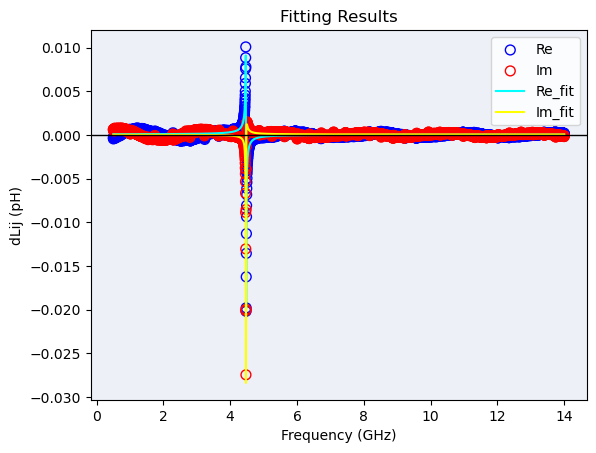


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.278e-04      7.200e-07         U        No
Ai                    -5.422e-05      7.200e-07         U        No
fo                        4.4717      3.421e-05       GHz        No
df                        0.0047      3.421e-05       GHz        No
re0                    4.639e-05      3.594e-06         U        No
im0                    4.508e-05      3.594e-06         U        No
----------------------------------------------------------------------
Guide freq.=3.606119009215397
74


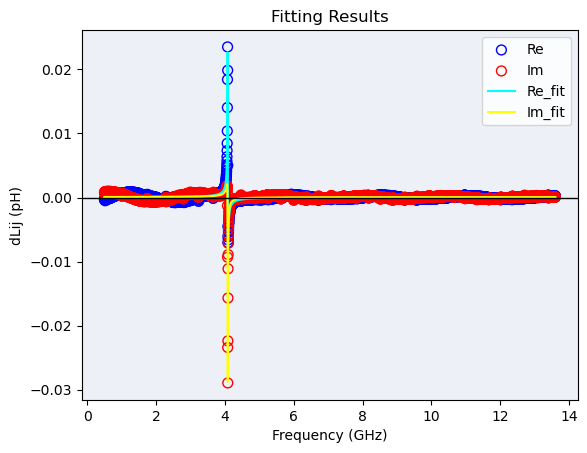


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.326e-04      8.482e-07         U        No
Ai                     7.583e-05      8.482e-07         U        No
fo                        4.0823      3.852e-05       GHz        No
df                        0.0049      3.852e-05       GHz        No
re0                    1.605e-05      4.188e-06         U        No
im0                    5.859e-05      4.188e-06         U        No
----------------------------------------------------------------------
Guide freq.=3.1954304151266957
75


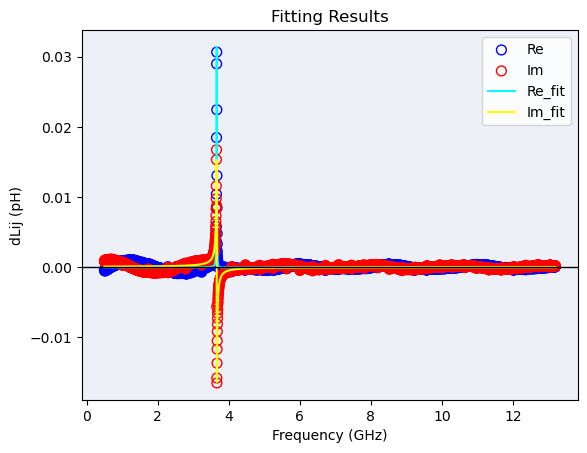


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -7.516e-06      1.003e-06         U        No
Ai                     1.685e-04      1.003e-06         U        No
fo                        3.6605      4.404e-05       GHz        No
df                        0.0052      4.404e-05       GHz        No
re0                   -1.617e-05      4.869e-06         U        No
im0                    3.549e-05      4.869e-06         U        No
----------------------------------------------------------------------
Guide freq.=2.798676852835876
76


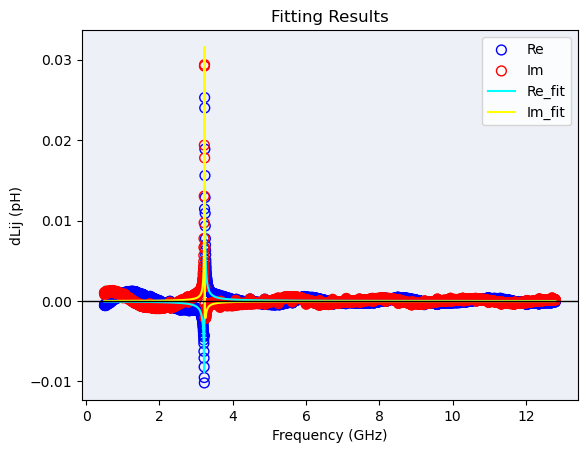


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.524e-04      1.149e-06         U        No
Ai                     8.404e-05      1.149e-06         U        No
fo                        3.2307      4.747e-05       GHz        No
df                        0.0051      4.747e-05       GHz        No
re0                   -9.495e-06      5.750e-06         U        No
im0                   -1.653e-05      5.750e-06         U        No
----------------------------------------------------------------------
Guide freq.=2.393137100355631
77


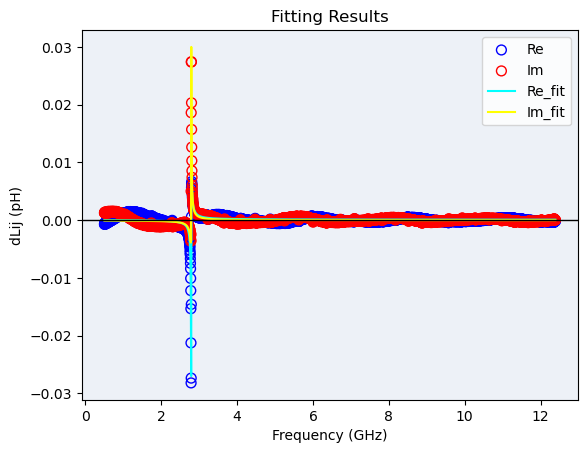


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.452e-04      1.448e-06         U        No
Ai                    -1.179e-04      1.448e-06         U        No
fo                        2.7892      5.957e-05       GHz        No
df                        0.0054      5.957e-05       GHz        No
re0                    5.954e-05      7.123e-06         U        No
im0                   -3.816e-05      7.123e-06         U        No
----------------------------------------------------------------------
Guide freq.=1.9444156213062505
78


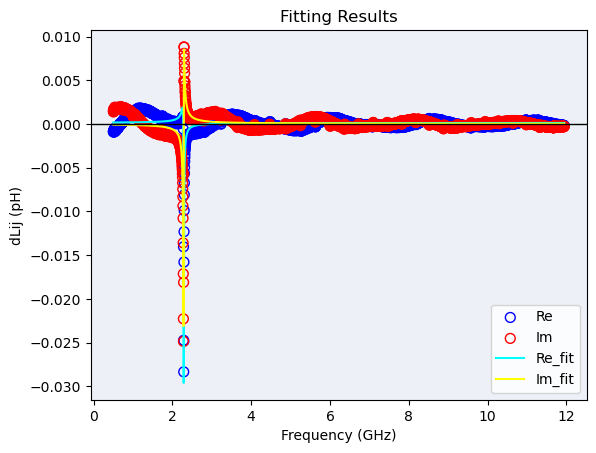


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.931e-05      1.852e-06         U        No
Ai                    -1.718e-04      1.852e-06         U        No
fo                        2.2845      8.256e-05       GHz        No
df                        0.0061      8.256e-05       GHz        No
re0                    1.313e-04      8.765e-06         U        No
im0                    2.525e-05      8.765e-06         U        No
----------------------------------------------------------------------
Guide freq.=1.4710642141063361
79


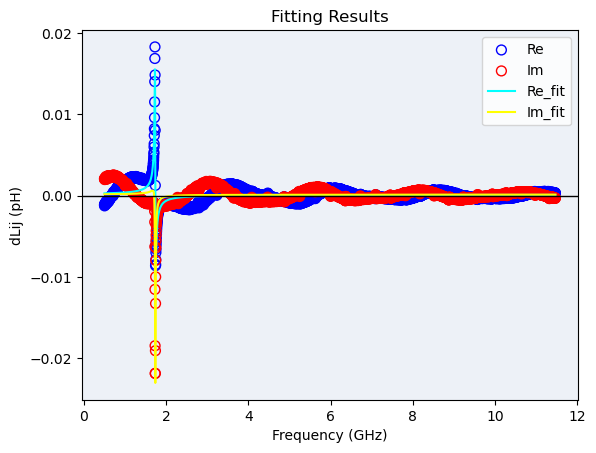


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.013e-04      2.901e-06         U        No
Ai                     5.980e-05      2.901e-06         U        No
fo                        1.7351      1.697e-04       GHz        No
df                        0.0087      1.697e-04       GHz        No
re0                    1.168e-04      1.173e-05         U        No
im0                    1.268e-04      1.173e-05         U        No
----------------------------------------------------------------------
Guide freq.=0.779394522466733
80


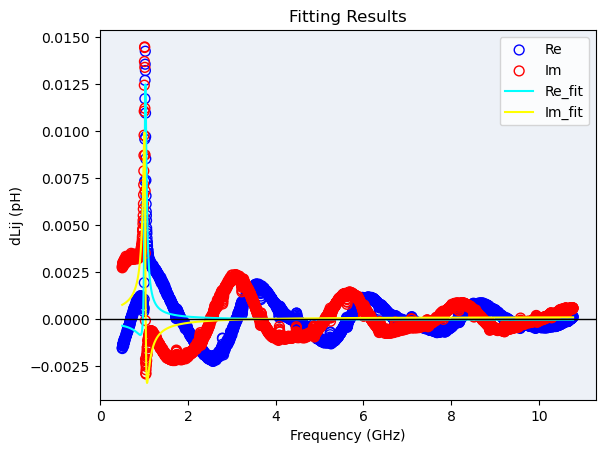


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.723e-04      6.950e-06         U        No
Ai                     3.218e-04      6.950e-06         U        No
fo                        1.0215      7.250e-04       GHz        No
df                        0.0274      7.250e-04       GHz        No
re0                   -6.535e-05      1.613e-05         U        No
im0                    1.146e-04      1.613e-05         U        No
----------------------------------------------------------------------


In [58]:
est_gamma = 28.8 #GHz/T
est_hx = 0.115 #T
est_hy = 0.00 #T

for i in range(len(ansy1.curr)):
    H_index = i
    freq = res_func.kittel_general(ansy1.calc_field("inP")[H_index],est_gamma, est_hx, est_hy)
    print(f"Guide freq.={freq}")
    print(H_index)
    ini_vals = [1, 1, freq, 0.028, 0, 0] #A, w, fres, fper, fref, re0, im0

    
    f_min, f_max = freq-10, freq+10 #GHz
    f_array = ansy1.freqs
    y_array_re, y_array_im = ansy1.d_S("21R")[H_index], ansy1.d_S("21I")[H_index]
    
    model = models.ComplexLorentzian_freq()
    fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
        f_array, y_array_re , y_array_im, model)
    fitter.fix(fo=freq, df=0.01, re0=0, im0=0) # Parameters to be fixed, empty otherwise
    opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
    #print(opt_p0)
    #fitter.plot_fit_simplex_wpm()
    new_p0 = np.array(list(opt_p0.values()), dtype=float)
    fitter.update_p0(new_p0)
    
    params, cov = fitter.fit(simplex_b=False)
    fitter.plot_fit()
    fitter.summary()
    fit_dict = fitter.export_fit_dict()
    fits_storage.save(index=H_index,field=float(ansy1.calc_field("inP")[H_index]),fit_dict=fit_dict)

In [ ]:
#Realoading parameters

In [22]:
data_L_fits = fits_storage.load_fit_results(newFile, group="Lorentzian fitting")

In [23]:
#Plotting of fitted parameters

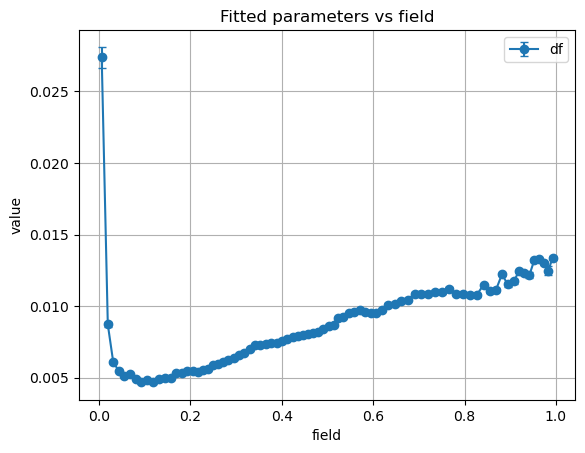

In [24]:
fits_storage.plot_fit_parameters(
    data_L_fits,
    x_axis="field",
    params=["df"]
)

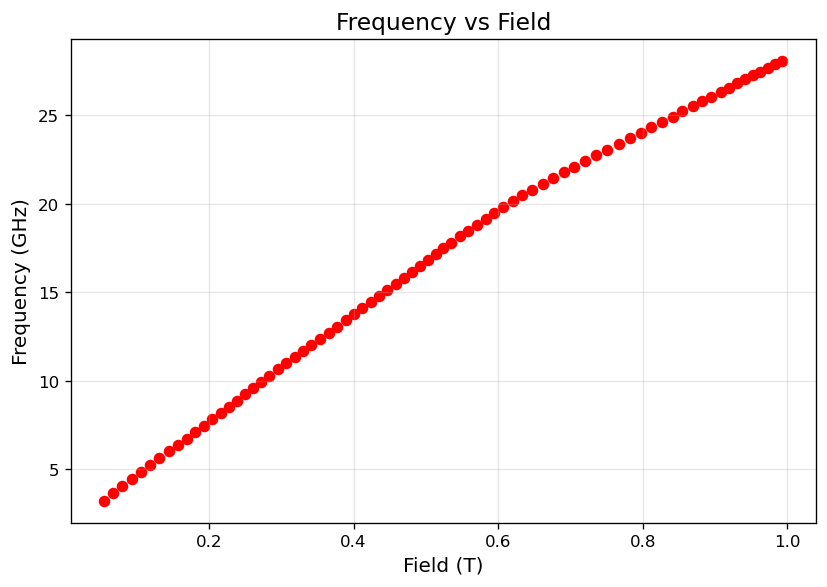

In [25]:
H = data_L_fits['field'][:-4]
fres = data_L_fits['fo'][:-4]

plt.figure(figsize=(7,5), dpi=120)

plt.scatter(H, fres, s=35, color="r")

plt.xlabel('Field (T)', fontsize=12)
plt.ylabel('Frequency (GHz)', fontsize=12)
plt.title('Frequency vs Field', fontsize=14)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

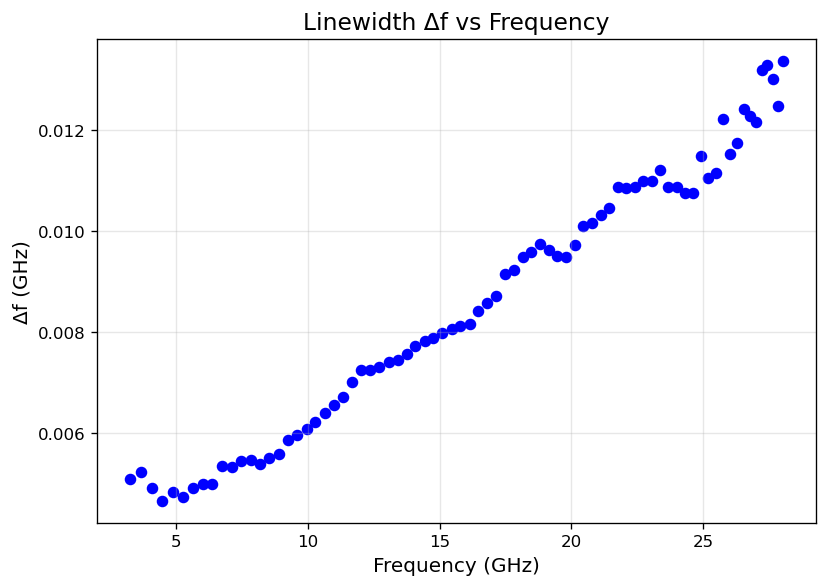

In [27]:
fres = data_L_fits['fo'][:-4]
df =  data_L_fits['df'][:-4]
plt.figure(figsize=(7,5), dpi=120)

plt.scatter(fres, df, s=35, color="b")

plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('Δf (GHz)', fontsize=12)
plt.title('Linewidth Δf vs Frequency', fontsize=14)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [133]:
gamma = 28.8   # GHz/T
Hx = 0.145     # T
Hy = 0.0       # T

# --- raw fitted data ---
H_raw  = data_L_fits['field']
f_raw  = data_L_fits['fo']
df_raw = data_L_fits['df']

# --- remove bad low-field fits ---
H  = H_raw[:-4]
f  = f_raw[:-4]


# --- linewidth conversion (Kittel-derived expression) ---
#dH = (2 * f * df) / (gamma * (2 * H + Hx + Hy)) (had to divide df by 2)
dH = (f * df) / (gamma * (2 * H + Hx + Hy))
# store it back for later reuse
data_L_fits['dH'] = dH

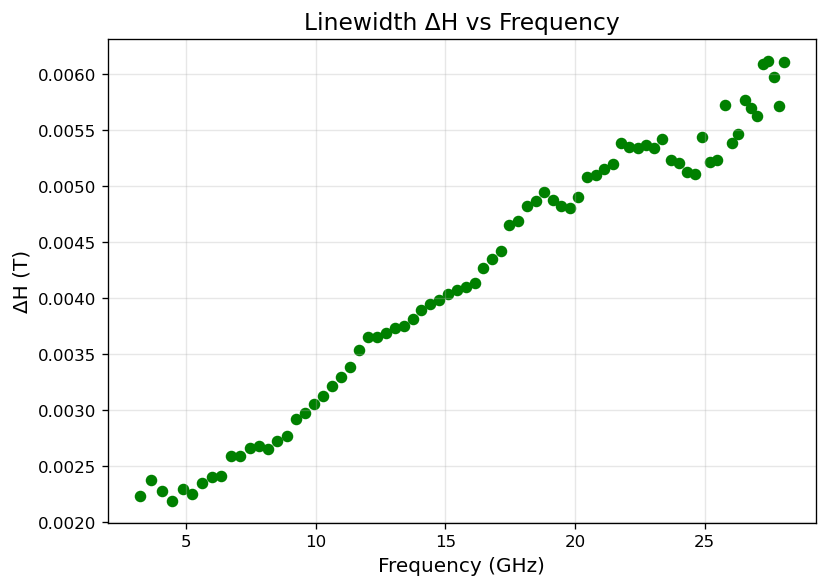

In [146]:
fres = data_L_fits['fo'][:-4]

plt.figure(figsize=(7,5), dpi=120)

plt.scatter(fres, dH, s=35, color="g")

plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('ΔH (T)', fontsize=12)
plt.title('Linewidth ΔH vs Frequency', fontsize=14)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [147]:
from scipy.stats import linregress
# Linear fit of dH vs frequency
fit = linregress(f, dH)

slope = fit.slope
intercept = fit.intercept
r2 = fit.rvalue**2

# Gilbert damping
alpha = slope * gamma / 2

print(f"Slope = {slope:.6e} T/GHz")
print(f"ΔH0 = {intercept:.6e} T")
print(f"R² = {r2:.6f}")
print(f"α = {alpha:.6e}")

Slope = 1.599241e-04 T/GHz
ΔH0 = 1.574517e-03 T
R² = 0.975291
α = 2.302907e-03


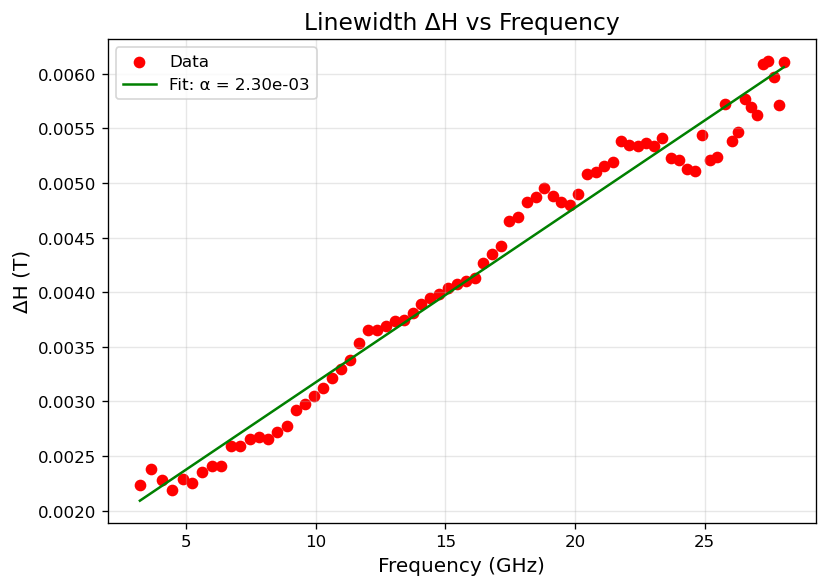

In [148]:
f_fit = np.linspace(f.min(), f.max(), 500)
dH_fit = slope*f_fit + intercept

plt.figure(figsize=(7,5), dpi=120)

plt.scatter(f, dH, label="Data", color="r")
plt.plot(f_fit, dH_fit,
         label=f"Fit: α = {alpha:.2e}", color = "g")

plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('ΔH (T)', fontsize=12)
plt.title('Linewidth ΔH vs Frequency', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


In [63]:
print(f[:10])
print(dH[:10])

[28.04460875 27.85374065 27.6549232  27.44377105 27.23488812 27.01828369
 26.7807875  26.54074004 26.29660205 26.03011832]
[0.00874993 0.00871039 0.00862562 0.00847956 0.00838784 0.00823056
 0.00815121 0.00812637 0.0081504  0.00823621]


In [64]:
print(f[-10:])
print(dH[-10:])

[8.1674646  7.80863115 7.44976218 7.09033697 6.71915701 6.3619012
 6.00201038 5.61903355 5.24237092 4.86909475]
[0.0040315  0.00489182 0.003798   0.0037011  0.00362978 0.00377763
 0.00365197 0.00345557 0.00327142 0.0034705 ]


In [ ]:
#Fitting f. resonance vs H to the Kittel model

In [3]:
H_data= data_L_fits["field"]
f_data= data_L_fits["fo"]


gamma_fix = True
gamma_fixed = 28.8

if gamma_fix:
    function = lambda H, Hx, Hy: res_func.kittel_general(H, gamma_fixed, Hx, Hy)
    p0 = [2.18, 0.04]  # initial guess: gamma ~ 28 GHz/T (electron-like)
    lower_bounds = [ 1.8, -1.0]
    upper_bounds = [2.5,  0.2]
else:
    function = res_func.kittel_general
    p0 = [28.8, 2.18, 0.04]  # initial guess: gamma ~ 28 GHz/T (electron-like)
    lower_bounds = [28.2, 1.8, -1.0]
    upper_bounds = [29.2,  2.5,  0.2]
    
popt, pcov = curve_fit(
    function,
    H_data,
    f_data,
    p0=p0,
    bounds=(lower_bounds, upper_bounds)
)


perr = np.sqrt(np.diag(pcov))  # 1-sigma errors

H_fit = np.linspace(H_data.min(), H_data.max(), 200)
if gamma_fix:
    Hx_fit, Hy_fit = popt
    f_fit = res_func.kittel_general(H_fit, gamma_fixed, Hx_fit, Hy_fit)
    gamma_fit=gamma_fixed
else:
    gamma_fit, Hx_fit, Hy_fit = popt
    f_fit = res_func.kittel_general(H_fit, gamma_fit, Hx_fit, Hy_fit)

plt.scatter(H_data, f_data, label="Resoance f.")

plt.plot(H_fit, f_fit, label="Kittel fit", color="red")

plt.xlabel("H (T)")
plt.ylabel("Frequency (GHz)")
plt.legend()
plt.show()
print(f"gamma={gamma_fit}GHz/T, Hx={Hx_fit}T, Hy={Hy_fit}T")

NameError: name 'data_L_fits' is not defined